# RETO 2:  Estacionalidad


El modelo turístico residencial concentra una parte muy importante de la actividad en verano y en otros periodos vacacionales. El objetivo de este reto es analizar la estacionalidad de Torrevieja y caracterizar sus patrones temporales.
El grupo deberá identificar si existen picos y valles de actividad, qué meses o semanas concentran mayor presión sobre el destino, y hasta qué punto los datos disponibles permiten describir esa estacionalidad.

Es necesario describir:

* la intensidad de la estacionalidad,
* su posible relación con la estructura residencial del destino,
* y sus implicaciones para la actividad turística, económica o de servicios

Como breve introducción nos gustaría mencionar que lo que pretendemos abordar a través de este segundo reto es un análisis de la estacionalidad del modelo turístico-residencial de Torrevieja, es decir, cómo se distribuye la actividad a lo largo del año, qué meses concentran la mayor presión, qué intensidad tiene esta estacionalidad y cómo se relaciona con la estructura residencial (hoteles vs VUT) y laboral. Para ello hemos cruzado 5 fuentes principales:
* el histórico de paro del SEPE
* los hoteles activos
* la población efectiva turística calculada en el reto 1
* las plazas de VUT del reto 3.
* datos de gasto turísticos del INE que hemos usado para estimar el gasto en la ciudad.

Así y con todo, las preguntas que se nos planteaban y que sí hemos podido abordar y responder de forma satisfactoria son:

1. ¿Existe estacionalidad en el paro?
2. ¿Existe estacionalidad en el turismo?
3. ¿Están el turismo y el paro correlacionados?
4. ¿Qué sectores soportan la estacionalidad laboral y cómo?
5. ¿Hay diferencias en el paro en cuanto a sexo/edad?
6. ¿Cómo se comportan el turismo nacional vs el extranjero?
7. ¿Por qué la oferta hotelera no explica los picos de turistas?
8. ¿Cuánto pesan las VUT frente a los hoteles?

No obstante, también hay preguntas que no hemos podido abordar/responder debido a las limitaciones de los datos.

1. Todas aquellas relacionadas con el gasto turístico en Torrevieja, pues no se pueden cuantificar las "implicaciones económicas" reales, solo las podemos estimar mediante una fórmula que hemos considerado acertada.
2. El nº real de segundas residencias activas mes a mes, pues solo tenemos una estimación indirecta via déficit de plazas.
3. La evolución histórica del modelo Torrevieja, que sería muy interesante y clave para entender el origen estructural y visualizar la evolución de una transición desde la pesca/salinas hacia el turismo residencial post franquismo cuando empezaron a abrirse las fronteras de España al turismo europeo.
4. Ocupación hotelera mensual, pues solo sabemos si el hotel está abierto, no cuantas plazas vende.
5. Y, por último, aquellas relacionadas con la capacidad y tensión de servicios públicos como camas hospitalarias, reisduos, agua... ya que sin ellas no se puede medir cuantitativamente la presión real sobre el destino.

In [145]:
%pip install pandas matplotlib xlrd openpyxl seaborn scipy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [146]:
# Vamos a transformar los jsons de los hoteles a parquets
import json
import pandas as pd
import os
from glob import glob
from datetime import datetime
import matplotlib.pyplot as plt
import xlrd
import openpyxl 
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [147]:


def json_to_dataframe(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Convertir a DataFrame
    df = pd.DataFrame(data)
    return df

    
df1 = json_to_dataframe('../DATASETS/RETO 2/hotels_historic.json')


df1.head()


,signatura,cod_estado,estado,codigo_categoria,categoria,nombre,prov_codigo,provincia,muni_codigo,localidad,...,codigo_modalidad,modalidad,hote_totalhab,hote_nplazas,cod_cadena,cadena,fecha_alta,fecha_baja,periodo,dias_periodo
0,CV H01188 A,B,BAJA,0,PENSIÃ“N,CANALEJAS,03,ALACANT,004,AIGÃœES,...,P,PENSIÃ“N,7,12.0,NCD,NO PERTENECE A NINGUNA CADENA,1999-04-11 10:00:00,2005-01-26 11:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
1,CV H01289 A,A,ALTA,1,1 ESTRELLA,ESTACIÃ“N DE SERVICIO LOS MARTÃNEZ,03,ALACANT,005,ALBATERA,...,HS,HOSTAL,23,42.0,NCD,NO PERTENECE A NINGUNA CADENA,2004-03-04 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
2,CV H00701 A,B,BAJA,0,PENSIÃ“N,LOS ANGELES,03,ALACANT,005,ALBATERA,...,P,PENSIÃ“N,4,6.0,NCD,NO PERTENECE A NINGUNA CADENA,1969-12-29 11:00:00,1992-09-15 10:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
3,CV H00097 A,B,BAJA,1,1 ESTRELLA,MOS DEL BOU,03,ALACANT,005,ALBATERA,...,SR,HOSTAL-RESIDENCIA,25,49.0,NCD,NO PERTENECE A NINGUNA CADENA,1962-03-20 11:00:00,2009-05-28 10:00:00,SIEMPRE ABIERTO,De Lunes a Domingo
4,CV H01415 A,A,ALTA,3,3 ESTRELLAS,CASTELL DE LA SOLANA,03,ALACANT,006,ALCALALÃ,...,H,HOTEL,7,14.0,NCD,NO PERTENECE A NINGUNA CADENA,2014-08-05 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo


In [148]:
# Filtramos por los datos de torrevieja
df1_torrevieja = df1[df1['localidad'] == 'TORREVIEJA']


df1_torrevieja.shape


(40, 31)

In [149]:
df1_torrevieja.columns

Index(['signatura', 'cod_estado', 'estado', 'codigo_categoria', 'categoria',
       'nombre', 'prov_codigo', 'provincia', 'muni_codigo', 'localidad',
       'comarca', 'cp', 'direccion', 'codigo_tipo_via', 'tipo_via', 'via',
       'numero', 'email', 'web', 'codigo_grupo', 'grupo', 'codigo_modalidad',
       'modalidad', 'hote_totalhab', 'hote_nplazas', 'cod_cadena', 'cadena',
       'fecha_alta', 'fecha_baja', 'periodo', 'dias_periodo'],
      dtype='str')

In [150]:
df1_torrevieja.head()

,signatura,cod_estado,estado,codigo_categoria,categoria,nombre,prov_codigo,provincia,muni_codigo,localidad,...,codigo_modalidad,modalidad,hote_totalhab,hote_nplazas,cod_cadena,cadena,fecha_alta,fecha_baja,periodo,dias_periodo
1009,CV H00925 A,A,ALTA,0,PENSIÃ“N,HB TORREVIEJA,03,ALACANT,133,TORREVIEJA,...,P,PENSIÃ“N,24,38.0,NCD,NO PERTENECE A NINGUNA CADENA,1974-12-09 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1010,CV H01505 A,A,ALTA,NaN,NaN,7A,03,ALACANT,133,TORREVIEJA,...,NaN,NaN,7,12.0,NCD,NO PERTENECE A NINGUNA CADENA,2019-06-27 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1011,CV H01312 A,A,ALTA,1,1 ESTRELLA,ALBA,03,ALACANT,133,TORREVIEJA,...,SR,HOSTAL-RESIDENCIA,11,19.0,NCD,NO PERTENECE A NINGUNA CADENA,2005-07-13 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1012,CV H01466 A,A,ALTA,3,3 ESTRELLAS,APARTHOTEL SOLE BELLO,03,ALACANT,133,TORREVIEJA,...,HA,HOTEL-APARTAMENTO,49,118.0,NCD,NO PERTENECE A NINGUNA CADENA,2017-08-02 10:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo
1013,CV H00771 A,A,ALTA,3,3 ESTRELLAS,AS HOTEL MADRID,03,ALACANT,133,TORREVIEJA,...,H,HOTEL,40,73.0,NCD,NO PERTENECE A NINGUNA CADENA,1971-03-09 11:00:00,NaN,SIEMPRE ABIERTO,De Lunes a Domingo


In [151]:
df = pd.read_csv('../DATASETS/RETO 2/paro_2025_1trim.csv', sep = ';', encoding='utf-8', skiprows=1)
#Filtramos por los datos de torrevieja

df.columns

Index(['mes', 'Código de CA', 'Comunidad Autónoma', 'Codigo Provincia',
       'Provincia', 'Codigo Municipio', ' Municipio', 'total Paro Registrado',
       'Paro hombre edad < 25', 'Paro hombre edad 25 -45 ',
       'Paro hombre edad >=45', 'Paro mujer edad < 25',
       'Paro mujer edad 25 -45 ', 'Paro mujer edad >=45', 'Paro Agricultura',
       'Paro Industria', 'Paro Construcción', 'Paro Servicios',
       'Paro Sin empleo Anterior'],
      dtype='str')

In [152]:
# Vamos a cargar los datos de la carpeta paro (tanto CSV como XLS)

# Cargar archivos CSV y XLS de la carpeta "paro"
csv_files = glob(os.path.join('..//DATASETS/RETO 2', '*.csv'))
xls_files = glob(os.path.join('..//DATASETS/RETO 2', '*.xls'))

print(f"Archivos CSV encontrados: {len(csv_files)}")
print(f"Archivos XLS encontrados: {len(xls_files)}")

# Lista para almacenar los DataFrames
dfs = []

# Función para procesar un DataFrame (aplicar a CSV y XLS)
def procesar_dataframe(df):
    """Procesa y limpia un DataFrame de paro"""
    
    # Limpiar espacios en los nombres de columnas
    df.columns = df.columns.str.strip()
    
    # ===== CONVERSIÓN A NUMÉRICO =====
    # PROBLEMA: Los archivos tienen columnas de tipo 'object' que mezclan strings y números
    # SOLUCIÓN: Convertir todas las columnas de paro a tipo numérico
    
    # Lista de columnas que necesitan conversión
    columnas_paro = [
        'total Paro Registrado',
        'Paro hombre edad < 25', 
        'Paro hombre edad 25 -45',
        'Paro hombre edad >=45', 
        'Paro mujer edad < 25',
        'Paro mujer edad 25 -45', 
        'Paro mujer edad >=45',
        'Paro Agricultura',
        'Paro Industria',
        'Paro Construcción',
        'Paro Servicios',
        'Paro Sin empleo Anterior'
    ]
    
    # Convertir cada columna a numérico
    for col in columnas_paro:
        if col in df.columns:
            # Reemplazar '<5' por 2 (valor medio entre 0 y 5)
            # El INE usa '<5' para proteger datos cuando hay menos de 5 casos
            df[col] = df[col].replace('<5', '2')
            # Convertir a numérico (errores se convierten a NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Filtrar por Torrevieja
    df = df[df['Municipio'] == 'Torrevieja']
    
    # Transformar la columna 'mes' a formato datetime
    df['fecha'] = pd.to_datetime(
        df['mes'].str.replace('Enero', 'January')
                 .str.replace('Febrero', 'February')
                 .str.replace('Marzo', 'March')
                 .str.replace('Abril', 'April')
                 .str.replace('Mayo', 'May')
                 .str.replace('Junio', 'June')
                 .str.replace('Julio', 'July')
                 .str.replace('Agosto', 'August')
                 .str.replace('Septiembre', 'September')
                 .str.replace('Octubre', 'October')
                 .str.replace('Noviembre', 'November')
                 .str.replace('Diciembre', 'December'),
        format='%B de %Y'
    )
    
    return df

# Procesar archivos CSV
for csv_file in csv_files:
    print(f"Procesando CSV: {os.path.basename(csv_file)}")
    df = pd.read_csv(csv_file, sep=';', encoding='utf-8', skiprows=1)
    df = procesar_dataframe(df)
    dfs.append(df)

# Procesar archivos XLS
for xls_file in xls_files:
    print(f"Procesando XLS: {os.path.basename(xls_file)}")
    # Leer archivo Excel (skiprows=1 para saltar la primera fila)
    df = pd.read_excel(xls_file, skiprows=1)
    df = procesar_dataframe(df)
    dfs.append(df)

# Concatenar todos los DataFrames en uno solo
df_paro = pd.concat(dfs, ignore_index=True)

# Ordenar por fecha
df_paro = df_paro.sort_values('fecha').reset_index(drop=True)

print(f"\nTotal de registros: {len(df_paro)}")
print(f"Rango de fechas: {df_paro['fecha'].min()} a {df_paro['fecha'].max()}")

df_paro.head()

Archivos CSV encontrados: 8
Archivos XLS encontrados: 7
Procesando CSV: paro_2025_1trim.csv
Procesando CSV: paro_2023_1trim.csv
Procesando CSV: paro_2024_1trim.csv
Procesando CSV: paro_2022_1trim.csv
Procesando CSV: paro_2019_1trim.csv
Procesando CSV: paro_2021_1trim.csv
Procesando CSV: paro_2026_1trim.csv
Procesando CSV: paro_2020_1trim.csv
Procesando XLS: paro_2020_2trim.xls
Procesando XLS: paro_2021_2trim.xls
Procesando XLS: paro_2019_2trim.xls
Procesando XLS: paro_2022_2trim.xls
Procesando XLS: paro_2024_2trim.xls
Procesando XLS: paro_2023_2trim.xls
Procesando XLS: paro_2025_2trim.xls

Total de registros: 64
Rango de fechas: 2019-01-01 00:00:00 a 2026-02-01 00:00:00


,mes,Código de CA,Comunidad Autónoma,Codigo Provincia,Provincia,Codigo Municipio,Municipio,total Paro Registrado,Paro hombre edad < 25,Paro hombre edad 25 -45,...,Paro mujer edad < 25,Paro mujer edad 25 -45,Paro mujer edad >=45,Paro Agricultura,Paro Industria,Paro Construcción,Paro Servicios,Paro Sin empleo Anterior,fecha,Código mes
0,Enero de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7897.0,278.0,1169.0,...,280.0,1818.0,2342.0,214.0,349.0,990.0,6168.0,176.0,2019-01-01,NaN
1,Febrero de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7903.0,298.0,1169.0,...,297.0,1794.0,2362.0,212.0,336.0,989.0,6169.0,197.0,2019-02-01,NaN
2,Julio de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,6252.0,152.0,807.0,...,150.0,1293.0,2083.0,183.0,271.0,940.0,4704.0,154.0,2019-07-01,201907.0
3,Agosto de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,6389.0,180.0,843.0,...,158.0,1344.0,2068.0,182.0,269.0,964.0,4826.0,148.0,2019-08-01,201908.0
4,Septiembre de 2019,10.0,Comunitat Valenciana,3.0,Alicante/Alacant,3133.0,Torrevieja,7008.0,240.0,985.0,...,229.0,1479.0,2203.0,173.0,342.0,945.0,5400.0,148.0,2019-09-01,201909.0


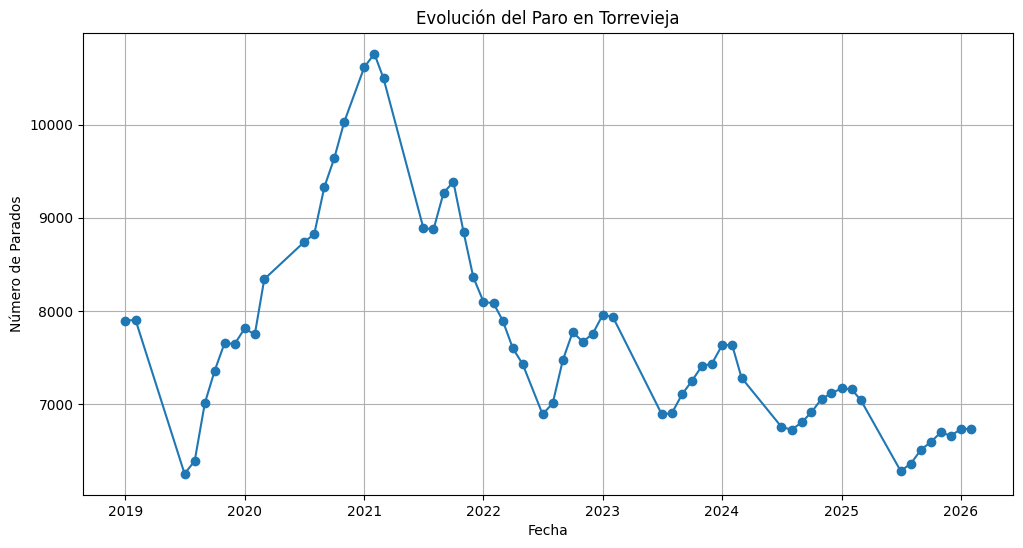

In [153]:
# Vamos a visualizar la evolución del paro en torrevieja a lo largo del tiempo. Para ello, vamos a agrupar por fecha y vamos a sumar el número de parados en cada fecha. Luego, vamos a graficar la evolución del paro a lo largo del tiempo.
# Agrupar por fecha y sumar el número de parados
df_paro_grouped = df_paro.groupby('fecha')['total Paro Registrado'].sum().reset_index()
# Graficar la evolución del paro a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total Paro Registrado'], marker='o')
plt.title('Evolución del Paro en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.grid()
plt.show()

Ya solo con esta gráfica podemos intuir el componente estacionario del paro en Torrevieja, por las subidas y bajadas que hace la curva a lo largo de los años, siendo el pico más alto en 2021, debido al covid.

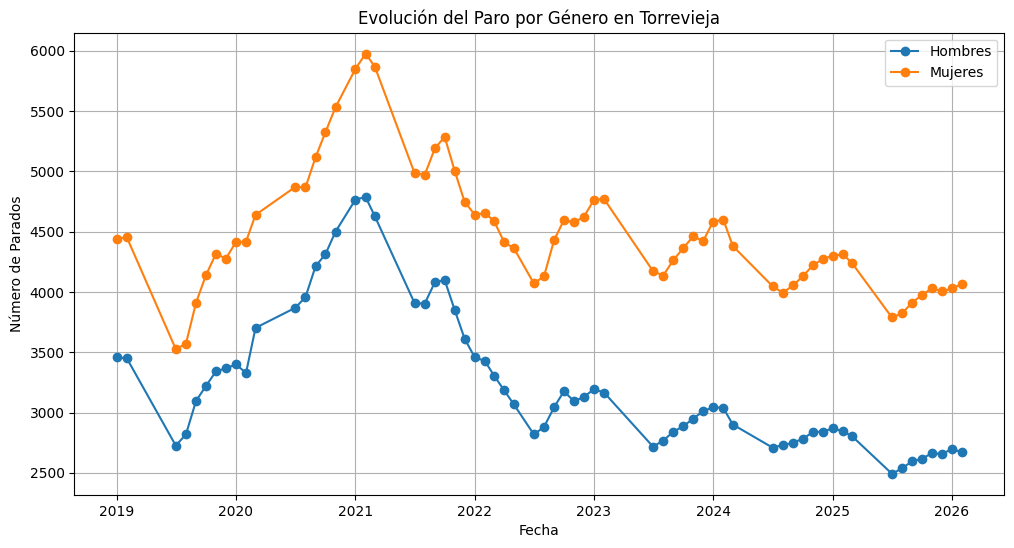

In [154]:
# Agrupar por fecha y calcular totales de paro por género
# Ya no necesitamos limpiar espacios ni convertir a numérico porque se hizo al cargar los datos

df_paro_grouped = df_paro.groupby('fecha').agg({
    'Paro hombre edad < 25': 'sum',
    'Paro hombre edad 25 -45': 'sum',
    'Paro hombre edad >=45': 'sum',
    'Paro mujer edad < 25': 'sum',
    'Paro mujer edad 25 -45': 'sum',
    'Paro mujer edad >=45': 'sum'
}).reset_index()

# Calcular totales por género
df_paro_grouped['total_hombres'] = (
    df_paro_grouped['Paro hombre edad < 25'] + 
    df_paro_grouped['Paro hombre edad 25 -45'] + 
    df_paro_grouped['Paro hombre edad >=45']
)

df_paro_grouped['total_mujeres'] = (
    df_paro_grouped['Paro mujer edad < 25'] + 
    df_paro_grouped['Paro mujer edad 25 -45'] + 
    df_paro_grouped['Paro mujer edad >=45']
)

# Graficar la evolución del paro por género a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total_hombres'], marker='o', label='Hombres')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['total_mujeres'], marker='o', label='Mujeres')
plt.title('Evolución del Paro por Género en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.legend()
plt.grid()
plt.show()

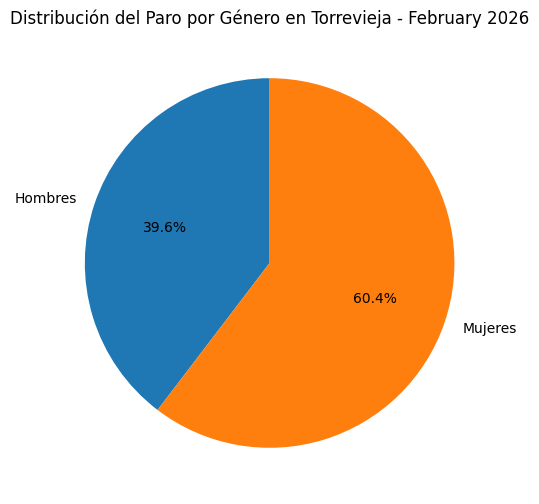

In [155]:
# Hacemos un gráfico de pie para ver la distribución del paro por género en el último mes disponible
ultimo_mes = df_paro_grouped['fecha'].max()
df_ultimo_mes = df_paro_grouped[df_paro_grouped['fecha'] == ultimo_mes]     
plt.figure(figsize=(6, 6))
plt.pie([df_ultimo_mes['total_hombres'].values[0], df_ultimo_mes['total_mujeres'].values[0]], labels=['Hombres', 'Mujeres'], autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución del Paro por Género en Torrevieja - {ultimo_mes.strftime("%B %Y")}')       
plt.show()  

En el último mes, hay más mujeres desempleadas en Torrvieja que hombres.

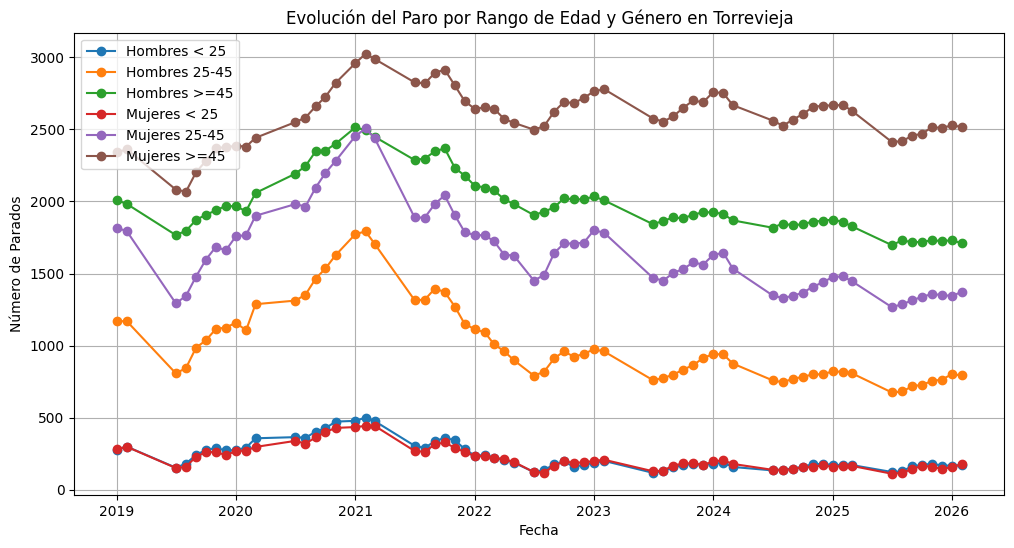

In [156]:
# Separando hombres y mujeres veamos las distribuciones por rango de edad en la suma de los años.
plt.figure(figsize=(12, 6))
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad < 25'], marker='o', label='Hombres < 25')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad 25 -45'], marker='o', label='Hombres 25-45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro hombre edad >=45'], marker='o', label='Hombres >=45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad < 25'], marker='o', label='Mujeres < 25')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad 25 -45'], marker='o', label='Mujeres 25-45')
plt.plot(df_paro_grouped['fecha'], df_paro_grouped['Paro mujer edad >=45'], marker='o', label='Mujeres >=45')   
plt.title('Evolución del Paro por Rango de Edad y Género en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Parados')
plt.legend()
plt.grid()
plt.show()

Si miramos la distribución, el grupo que más paro histórico sufre desde 2019 es el de las mujeres con edad mayor o igualq ue 45, seguidas de los hombres con edad mayor o igual que 45.
se debe en parte a que la edad activa laboral en este grupo comprende un rango mucho más pequeño, de los 18 alos 25, o, a lo sumo, de los 16 a los 25, por lo que obviamente hay menos datos. 

Esto se suma a que la población de Torrevieja es una población más bien envejecida, pues una parte significativa de la población se encuentra en tramos de edad avanzada, destacando más de 10.900 personas entre 70 y 79 años, y más de 5.000 residentes entre 80 y 89 años (datos extraídos de torrevieja.es).

Un último punto a destacar es que en el grupo de edad más joven, la desigualdad laboral es mucho menor, lo cual es un factor optimista de cómo evoluciona la sociedad hacia una más equitativa y en la que hay más igualdad de oportunidades para hombres y mujeres.

A continuación vamos a ver una evolución del paro en la ciudad pero mensualmente, para evaluar si existe algún patrón específico que se repita a lo largo de los años.
Esta vez no vamos a diferenciar entre hombres y mujeres sino que vamos a tomar los datos completos.


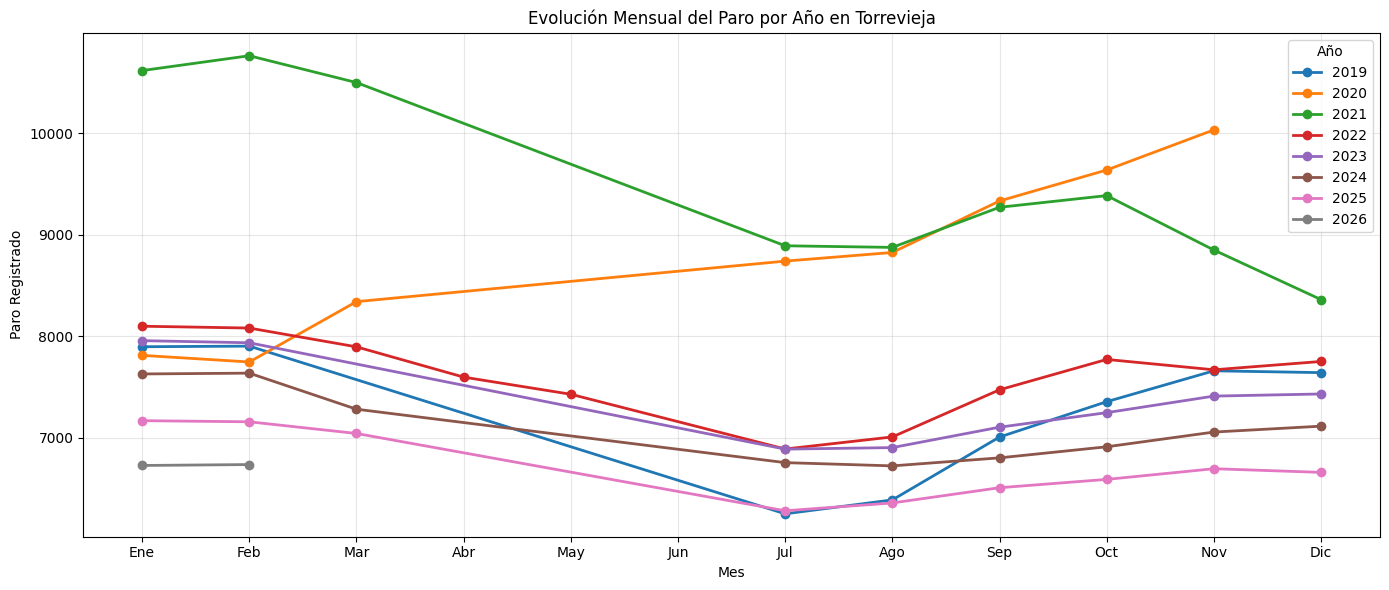

In [157]:
# Extraer año y mes
df_paro['año'] = df_paro['fecha'].dt.year
df_paro['mes_num'] = df_paro['fecha'].dt.month

# Graficar cada año como una línea separada
plt.figure(figsize=(14, 6))
for año in sorted(df_paro['año'].unique()):
    df_año = df_paro[df_paro['año'] == año]
    plt.plot(df_año['mes_num'], df_año['total Paro Registrado'], 
             marker='o', label=str(año), linewidth=2)

plt.title('Evolución Mensual del Paro por Año en Torrevieja')
plt.xlabel('Mes')
plt.ylabel('Paro Registrado')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Aunque las curvas para 2020 y 2021 se comporten de manera diferente, lo cual es lógico. Pero está claro que el resto de curvas se comportan de una manera muy muy parecida. Está claro que existe un patrón estacional, coincidiendo los meses de verano: junio, julio  y agosto con los de menos paro en todos los años; y los meses de invierno con los de más paro. 

Por tanto, el paro en Torrevieja tiene una estacionalidad anual.

A continuación vamos a hacer una comparativa de la evolución del paro y la cantidad de hoteles activos en la ciudad.

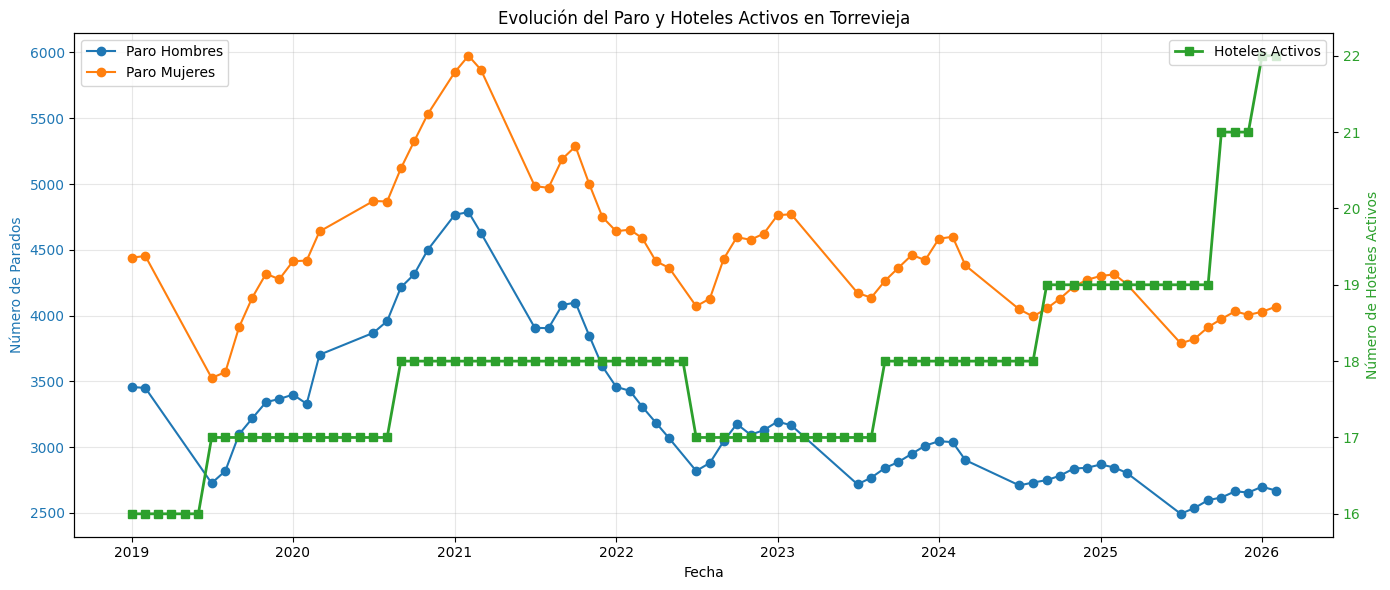

In [158]:
# Calcular hoteles activos en cada mes (considerando altas y bajas)
df1_torrevieja['fecha_alta'] = pd.to_datetime(df1_torrevieja['fecha_alta'])
df1_torrevieja['fecha_baja'] = pd.to_datetime(df1_torrevieja['fecha_baja'])

# Crear rango de fechas
fecha_min = df_paro_grouped['fecha'].min()
fecha_max = df_paro_grouped['fecha'].max()
fechas = pd.date_range(fecha_min, fecha_max, freq='MS')

# Contar hoteles activos en cada fecha
hoteles_activos = []
for fecha in fechas:
    activos = df1_torrevieja[
        (df1_torrevieja['fecha_alta'] <= fecha) & 
        ((df1_torrevieja['fecha_baja'].isna()) | (df1_torrevieja['fecha_baja'] > fecha))
    ].shape[0]
    hoteles_activos.append(activos)

df_hoteles_grouped = pd.DataFrame({
    'fecha': fechas,
    'total_hoteles': hoteles_activos
})

fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo: Paro
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Número de Parados', color='tab:blue')
ax1.plot(df_paro_grouped['fecha'], df_paro_grouped['total_hombres'], 
         marker='o', color='tab:blue', label='Paro Hombres')
ax1.plot(df_paro_grouped['fecha'], df_paro_grouped['total_mujeres'], 
         marker='o', color='tab:orange', label='Paro Mujeres')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Eje derecho: Hoteles
ax2 = ax1.twinx()
ax2.set_ylabel('Número de Hoteles Activos', color='tab:green')
ax2.plot(df_hoteles_grouped['fecha'], df_hoteles_grouped['total_hoteles'], 
         marker='s', color='tab:green', label='Hoteles Activos', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc='upper right')

plt.title('Evolución del Paro y Hoteles Activos en Torrevieja')
fig.tight_layout()
plt.show()


De esta gráfica podemos extraer varias conclusiones:

* Pico de paro en 2021 (COVID-19): el paro alcanza su máximo histórico: ~4,800 hombres y ~5,900 mujeres
Los hoteles se mantienen estables (~18), lo que sugiere que aunque los hoteles estaban abiertos, había menos turismo/actividad
Las mujeres fueron más afectadas que los hombres como ya hemos mencionado anteriormente.

* Desde 2021: existe una tendencia decreciente del paro, pues baja progresivamente de ~10,700 (2021) a ~6,800 (2026).
Los hotele, por su parte se mantienen relativamente estables (17-18) hasta 2024.

* En 2025-2026: destaca la presencia de una correlación positiva, pues podemos ver un aumento significativo de hoteles: De 19 a 22 (+16%) y un descenso acelerado del paro: Especialmente en hombres.

En este tramo temporal SÍ parece que "a más hoteles, menos paro", aunque hay que mencionar que, en general, esta relación no es directa siempre ni causal, sino que ambas variables reflejan la recuperación económica post-covid.

 
Solo hemos cogido los datos del paro desde 2019, porque los datos que tenemos del turismo en Torrevieja en los que hemos profundizado más en el reto 1 solo son desde 2019, y la idea en este reto es relacionar ambas cosas, aunque hemos de decir que el gobierno de la Comunidad Valenciana sí que dispone de los datos del paro desde fechas mucho más anteriores a 2019. En un futuro trabajo sería bastante interesante estudiar esta relación paro-hoteles remontándonos históricamente a mucho antes, incluso ver la evolución durante la dictadura franquista y la post-dictadura pues estas zonas del Levante como Benidorm y Torrevieja destacan por haber vivido  un boom económico y demográfico masivo tras la dictadura, transformándose, en el caso de Torrevieja, de un pueblo dedicado a la sal y la pesca en uno de los principales núcleos turísticos y de residencia de la cuenca mediterránea (información extraída de rua.ua.es).

Por tanto, como conclusión, no es tanto que "más hoteles causen menos paro" (o al menos no en este rango de fechas), sino que ambos indican recuperación económica. Un turismo fuerte (más hoteles activos) genera empleo indirecto en toda la cadena: restauración, comercio, transporte, limpieza, construcción, etc.

A continuación vamos a cargar los datos ya limpios y procesados del reto 1, de la evolución turística, tanto nacional como internacional, pues el objetivo de este reto es estudiar la estacionalidad de dichos datos. Posteriormente podremos compararlos con los de la actividad laboral en la ciudad.

Vamos a cargar tantos los datos de turistas extranjeros como nacionales.

In [159]:
poblacion_efectiva = pd.read_csv('../DATASETS/RETO 1/DATASETS MODIFICADOS/poblacion_efectiva_torrevieja.csv', sep=';', encoding='utf-8')

poblacion_efectiva.columns

Index(['fecha', 'turismo_interno', 'turismo_receptor', 'turismo_emisor', 'año',
       'poblacion_base', 'poblacion_efectiva'],
      dtype='str')

In [160]:
# La nueva versión del dataset ya viene agregada por mes (no por país de origen),
# con tres columnas: turismo_interno (nacional), turismo_receptor (extranjero) y turismo_emisor.
# Mantenemos los nombres de variables del notebook para no tocar el resto del análisis:
#   - turismo_extr        ←  columna 'turismo_receptor'  (turismo extranjero)
#   - turismo_nacional    ←  columna 'turismo_interno'   (turismo nacional)

poblacion_efectiva['fecha'] = pd.to_datetime(poblacion_efectiva['fecha'])
poblacion_efectiva['mes_num'] = poblacion_efectiva['fecha'].dt.month
poblacion_efectiva['mes_nombre'] = poblacion_efectiva['fecha'].dt.strftime('%B')

turismo_extr = (
    poblacion_efectiva[['fecha', 'año', 'mes_num', 'mes_nombre', 'turismo_receptor']]
    .rename(columns={'turismo_receptor': 'turistas'})
    .copy()
)

poblacion_efectiva.head()

,fecha,turismo_interno,turismo_receptor,turismo_emisor,año,poblacion_base,poblacion_efectiva,mes_num,mes_nombre
0,2019-07-01,89907,67182.0,2268,2019,80651,235472.0,7,July
1,2019-08-01,127890,76558.0,2998,2019,80651,282101.0,8,August
2,2019-09-01,43201,52157.0,3327,2019,80651,172682.0,9,September
3,2019-10-01,17576,50408.0,2695,2019,80651,145940.0,10,October
4,2019-11-01,14819,31650.0,2494,2019,80651,124626.0,11,November


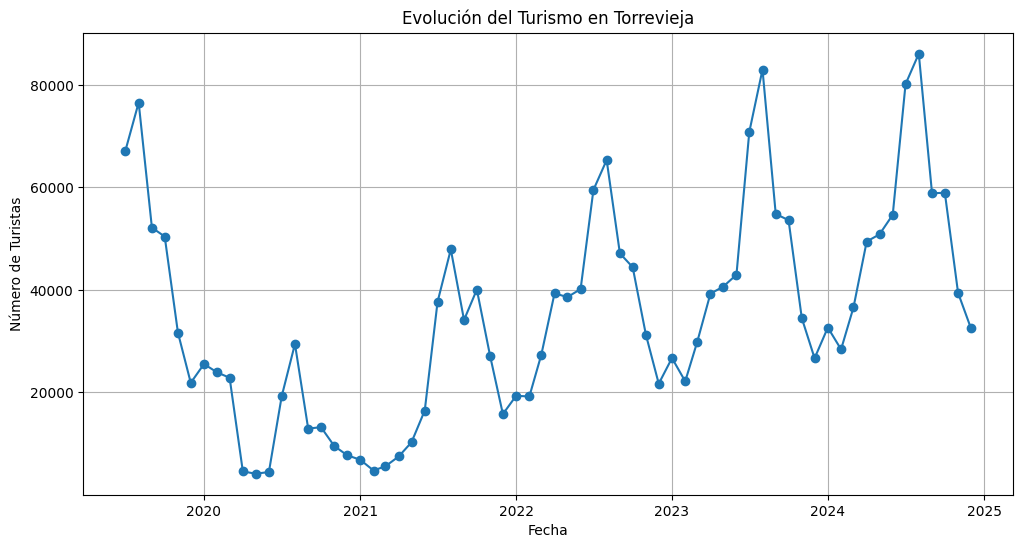

In [161]:
# Evolución del turismo extranjero a lo largo del tiempo (los datos ya vienen agregados por mes).
plt.figure(figsize=(12, 6))
plt.plot(turismo_extr['fecha'], turismo_extr['turistas'], marker='o')
plt.title('Evolución del Turismo en Torrevieja')
plt.xlabel('Fecha')
plt.ylabel('Número de Turistas')
plt.grid()
plt.show()

Claramente la gráfica muestra un componente estacionalidad. Vamos a hacer la misma gráfica pero separando por año, para ver que el mismo patrón se repite año a año.

Registros: 66

Primeros registros:
       fecha   año  mes_num  turistas
0 2019-07-01  2019        7   67182.0
1 2019-08-01  2019        8   76558.0
2 2019-09-01  2019        9   52157.0
3 2019-10-01  2019       10   50408.0
4 2019-11-01  2019       11   31650.0
5 2019-12-01  2019       12   21874.0
6 2020-01-01  2020        1   25532.0
7 2020-02-01  2020        2   23893.0
8 2020-03-01  2020        3   22859.0
9 2020-04-01  2020        4    4583.0


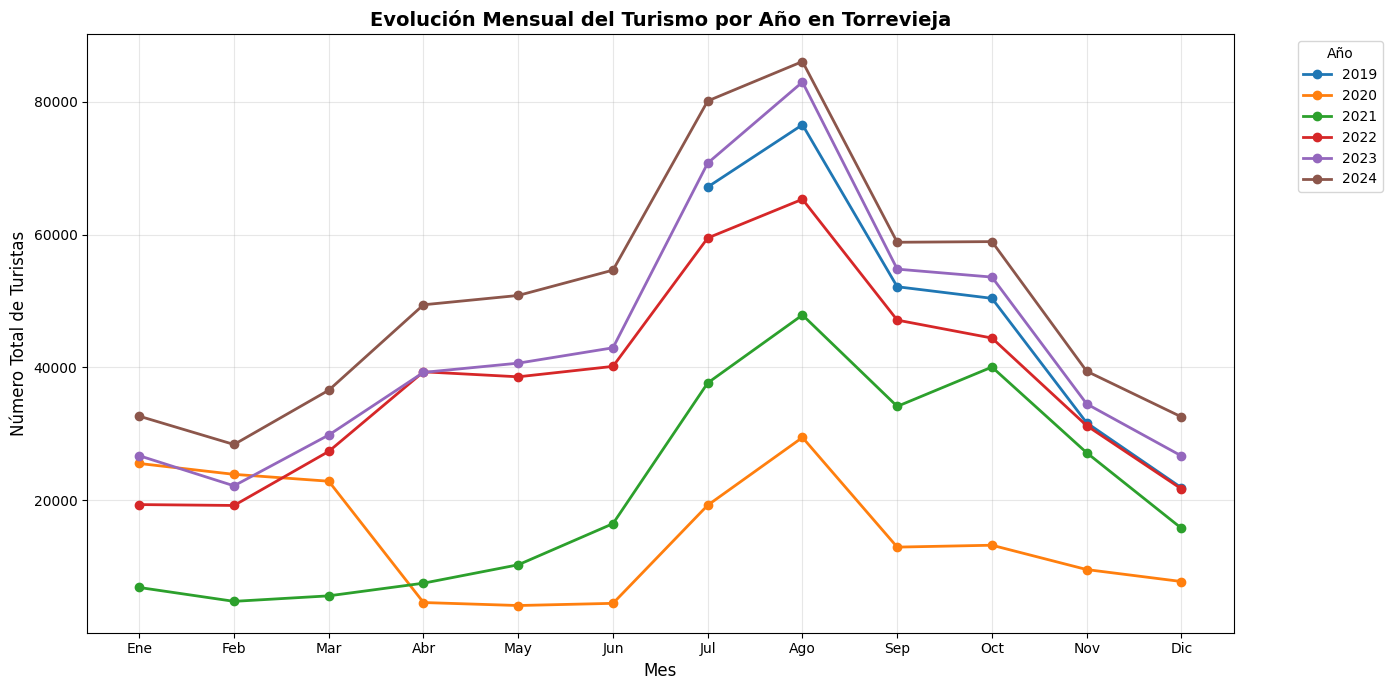

In [162]:
# Los datos ya vienen agregados por mes, así que solo seleccionamos las columnas necesarias.
turismo_agrupado = turismo_extr[['fecha', 'año', 'mes_num', 'turistas']].copy()

print(f"Registros: {len(turismo_agrupado)}")
print("\nPrimeros registros:")
print(turismo_agrupado.head(10))


# Graficar cada año como una línea separada
plt.figure(figsize=(14, 7))

for año in sorted(turismo_agrupado['año'].unique()):
    df_año = turismo_agrupado[turismo_agrupado['año'] == año].sort_values('mes_num')
    plt.plot(df_año['mes_num'], df_año['turistas'], 
             marker='o', label=str(año), linewidth=2, markersize=6)

plt.title('Evolución Mensual del Turismo por Año en Torrevieja', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número Total de Turistas', fontsize=12)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Efectivamente, el patrón es claro. La evolución del turismo en Torrevieja presenta un periodo anual. Los turistas caen en los meses más fríos y suben en los meses cálidos, a excepción de 2020 que parece que los turistas se quedaron hasta marz y ya a partir de este mes se fueron. El patrón parece inversamente proporcional al del paro, luego está claro que ambas variables están correlacionadas, tal y como ya habíamos deducido anteriormente.

Podemos estudiar esta misma gráfica pero solo considerando los turistas provenientes de España y solo los turistas extranjeros.

In [163]:
# Derivamos turismo_nacional del mismo dataset poblacion_efectiva
# (ya no hace falta cargar interno_torrevieja_limpio.csv).
turismo_nacional = (
    poblacion_efectiva[['fecha', 'año', 'mes_num', 'mes_nombre', 'turismo_interno']]
    .rename(columns={'turismo_interno': 'turistas'})
    .copy()
)

turismo_nacional.columns

Index(['fecha', 'año', 'mes_num', 'mes_nombre', 'turistas'], dtype='str')

In [164]:
turismo_nacional.head()

,fecha,año,mes_num,mes_nombre,turistas
0,2019-07-01,2019,7,July,89907
1,2019-08-01,2019,8,August,127890
2,2019-09-01,2019,9,September,43201
3,2019-10-01,2019,10,October,17576
4,2019-11-01,2019,11,November,14819


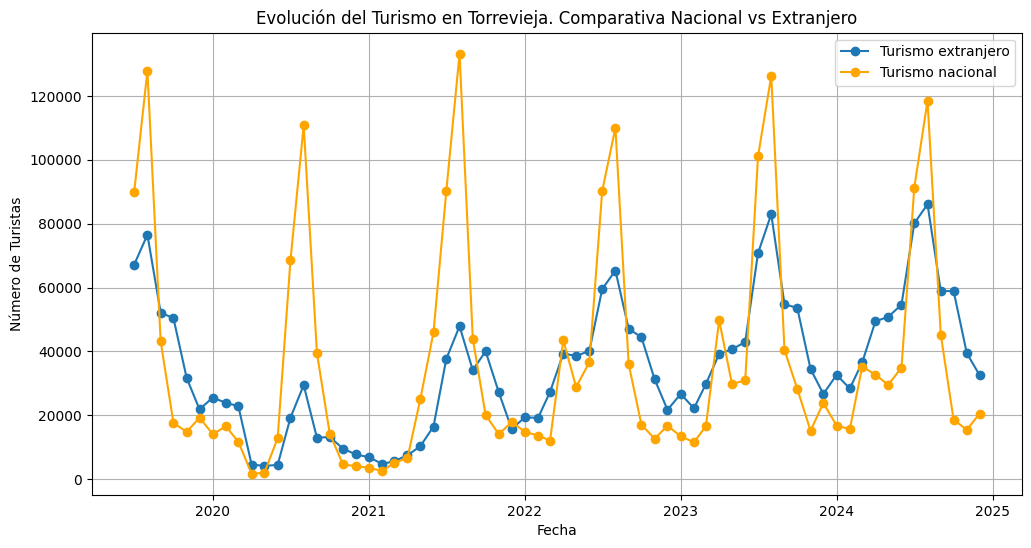

In [165]:
# Comparativa turismo nacional vs extranjero (ya están agregados por mes).
plt.figure(figsize=(12, 6))
plt.plot(turismo_extr['fecha'], turismo_extr['turistas'], marker='o', label='Turismo extranjero')
plt.plot(turismo_nacional['fecha'], turismo_nacional['turistas'], marker='o', color='orange', label='Turismo nacional')
plt.title('Evolución del Turismo en Torrevieja. Comparativa Nacional vs Extranjero')
plt.xlabel('Fecha')
plt.ylabel('Número de Turistas')
plt.grid()
plt.legend()
plt.show()

Está claro que hay más turistas extranjeros que nacionales. No obstante, lo interesante no es ver quién gana a quién sino cómo ha ido evolucionando la distancia entre las dos líneas conforme pasan los años, pues en 2021 y 2022 estaban casi a la par (lo cual es muy probable que sea debido al covid) y en 2022 empezaron a separarse, y esta separación se ha ido haciendo más notoria con los años.

El verano de 2025 ha sido la época vacacional que menos turistas nacionales ha recibido Torrevieja.

Ya intuímos que el patrón periódico del turismo nacional es igual que el extranjero, con un periodo anual. Igualmente lo graficamos separando por año.

Registros: 66

Primeros registros:
       fecha   año  mes_num  turistas
0 2019-07-01  2019        7     89907
1 2019-08-01  2019        8    127890
2 2019-09-01  2019        9     43201
3 2019-10-01  2019       10     17576
4 2019-11-01  2019       11     14819
5 2019-12-01  2019       12     19240
6 2020-01-01  2020        1     14124
7 2020-02-01  2020        2     16504
8 2020-03-01  2020        3     11707
9 2020-04-01  2020        4      1695


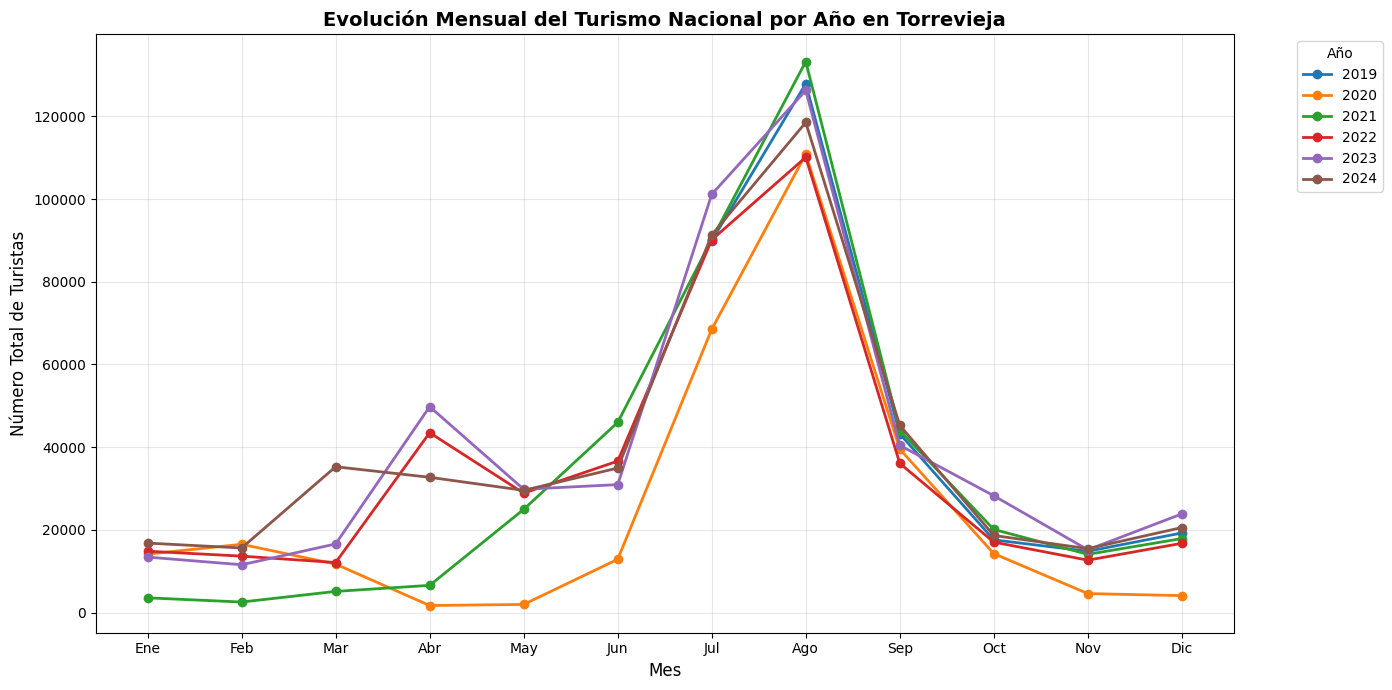

In [166]:
# Los datos ya vienen agregados por mes, así que solo seleccionamos las columnas necesarias.
turismo_agrupado2 = turismo_nacional[['fecha', 'año', 'mes_num', 'turistas']].copy()

print(f"Registros: {len(turismo_agrupado2)}")
print("\nPrimeros registros:")
print(turismo_agrupado2.head(10))


# Graficar cada año como una línea separada
plt.figure(figsize=(14, 7))

for año in sorted(turismo_agrupado2['año'].unique()):
    df_año = turismo_agrupado2[turismo_agrupado2['año'] == año].sort_values('mes_num')
    plt.plot(df_año['mes_num'], df_año['turistas'], 
             marker='o', label=str(año), linewidth=2, markersize=6)

plt.title('Evolución Mensual del Turismo Nacional por Año en Torrevieja', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número Total de Turistas', fontsize=12)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Las curvas para 2020 y 2021 están separadas de las demás, obviamente, pero no están tan separadas como lo estaban en la gráfica equivalente para el turismo extranjero.
Esto nos puede dar una pista clave: y es que gran parte del turismo nacional que recibe Torrevieja se debe a las segundas residencias de los españoles en esa ciudad.
O, si no son segundas residencias como tal, pueden ser casas de familiares o amigos cercanos, que permitan estancias veraniegas allí incluso en situaciones más extremas como el coronavirus.

Vamos a graficar el turismo nacional frente al paro nacional pues ya hemos comprobado que ambas variables presentan una estacionalidad anual muy marcada.

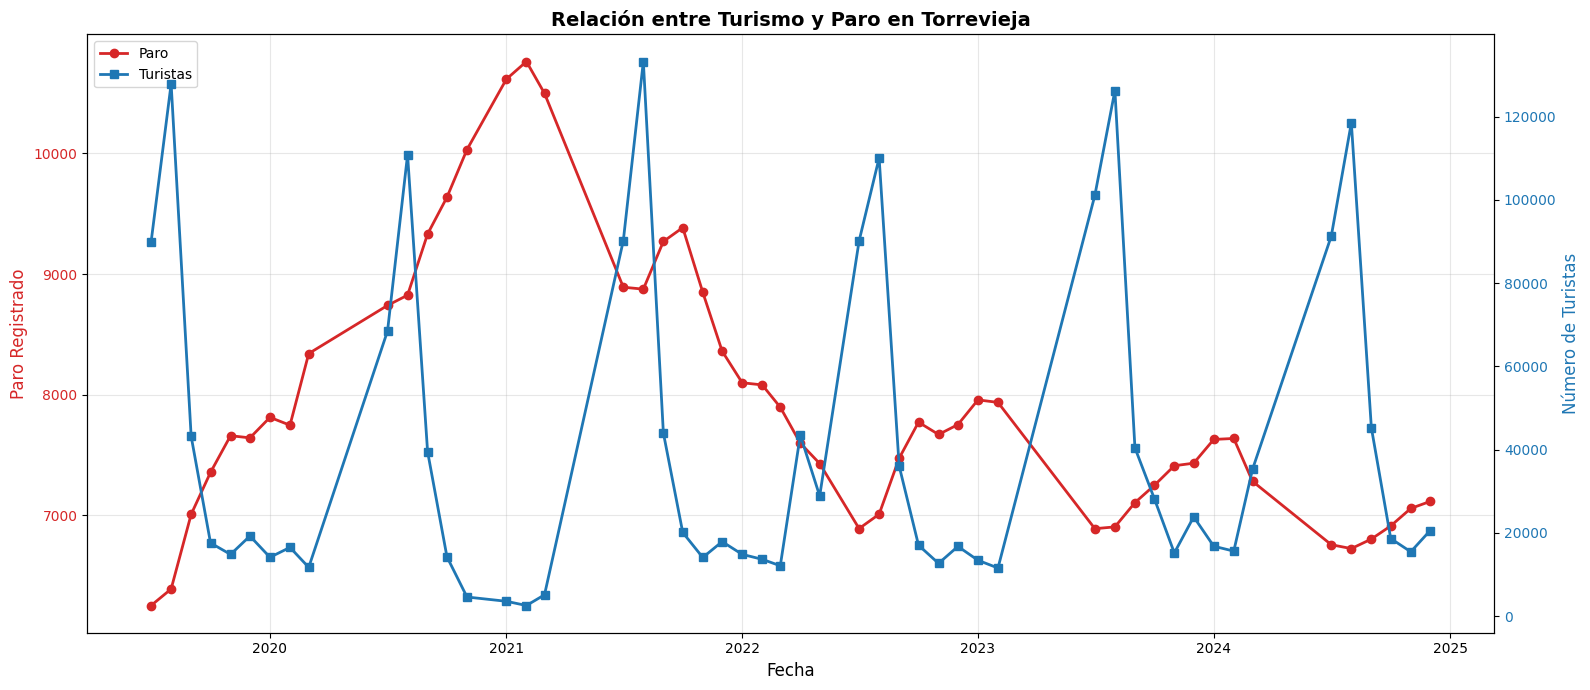

In [167]:
# Primero, asegúrate de tener ambos datasets agrupados por fecha
turismo_mensual = turismo_agrupado2.copy()
paro_mensual = df_paro.groupby('fecha').agg({
    'total Paro Registrado': 'sum'
}).reset_index()

# Merge de ambos datasets
comparacion = pd.merge(turismo_mensual, paro_mensual, on='fecha', how='inner')

# Gráfica de doble eje
fig, ax1 = plt.subplots(figsize=(16, 7))

# Eje izquierdo: Paro
color1 = 'tab:red'
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Paro Registrado', color=color1, fontsize=12)
ax1.plot(comparacion['fecha'], comparacion['total Paro Registrado'], 
         color=color1, linewidth=2, marker='o', label='Paro')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Eje derecho: Turismo
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Número de Turistas', color=color2, fontsize=12)
ax2.plot(comparacion['fecha'], comparacion['turistas'], 
         color=color2, linewidth=2, marker='s', label='Turistas')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Relación entre Turismo y Paro en Torrevieja', fontsize=14, fontweight='bold')

# Añadir leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()


Se cumple nuestra teoría. En el punto más alto de turismo se da el punto más bajo de paro y así sucesivamente todos los años. Como diferencia a destacar, el turismo sí que se ha mantenido más o menos constante a lo largo de los años, con pequeñas diferencias. No obstante, el paro, auque manteniendo el mismo patrón estacional, sí que se ha ido reduciendo. Pero no nos dejemos engañar por esto, pues se debe a que gran parte de la población trabajadora de Torrevieja emigra a otras zonas de España con una mayor oferta laboral, y la población de Torrevieja se queda como ya mencionamos anteriormente, envejecida.

El pronóstico es claro, en unos años Torrevieja será un Benidorm 2, llena de extranjeros alemanes y/o británicos jubilados.

Podemos estudiar la correlación entre el paro y el turismo nacional de una forma más teórica calculando el coeficiente de correlación de Pearson

Matriz de correlación:
                       turistas  total Paro Registrado
turistas               1.000000              -0.359065
total Paro Registrado -0.359065               1.000000


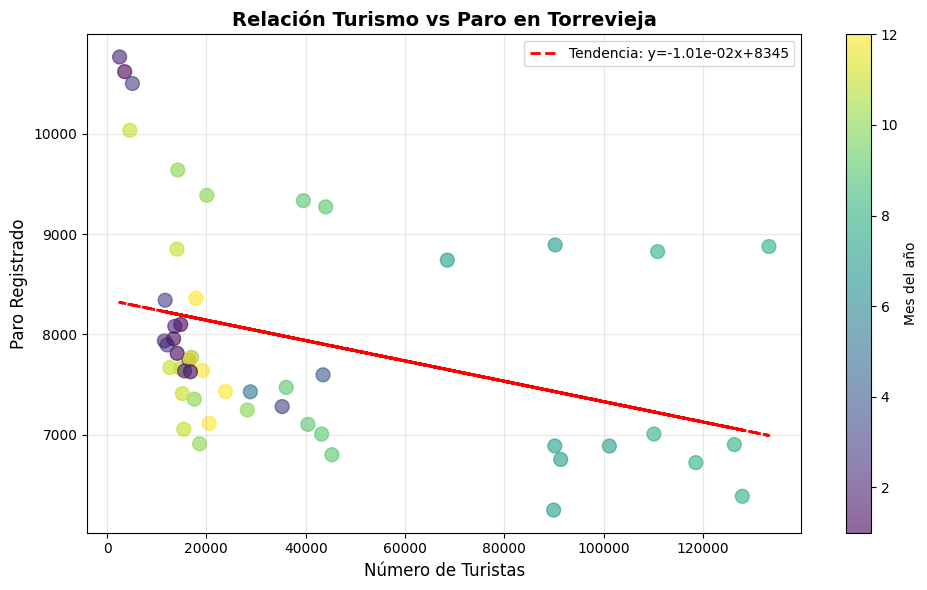


Coeficiente de correlación de Pearson: -0.359
P-value: 0.0097
✅ La correlación es estadísticamente significativa


In [168]:
# Calcular correlación
correlacion = comparacion[['turistas', 'total Paro Registrado']].corr()
print("Matriz de correlación:")
print(correlacion)

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(comparacion['turistas'], comparacion['total Paro Registrado'], 
            alpha=0.6, s=100, c=comparacion['mes_num'], cmap='viridis')
plt.colorbar(label='Mes del año')
plt.xlabel('Número de Turistas', fontsize=12)
plt.ylabel('Paro Registrado', fontsize=12)
plt.title('Relación Turismo vs Paro en Torrevieja', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Línea de tendencia
z = np.polyfit(comparacion['turistas'], comparacion['total Paro Registrado'], 1)
p = np.poly1d(z)
plt.plot(comparacion['turistas'], p(comparacion['turistas']), 
         "r--", linewidth=2, label=f'Tendencia: y={z[0]:.2e}x+{z[1]:.0f}')
plt.legend()
plt.tight_layout()
plt.show()

# Calcular coeficiente de correlación

corr, p_value = pearsonr(comparacion['turistas'], comparacion['total Paro Registrado'])
print(f"\nCoeficiente de correlación de Pearson: {corr:.3f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ La correlación es estadísticamente significativa")
else:
    print("❌ La correlación NO es estadísticamente significativa")


Por último, para cuantificar la estacionalidad de una forma estadística también podemos sacar diversos coeficientes y ratios.

In [169]:
# Coeficiente de Variación (CV) - mide intensidad de estacionalidad
turistas_mes = comparacion.groupby('mes_num')['turistas'].mean()
paro_mes = comparacion.groupby('mes_num')['total Paro Registrado'].mean()

cv_turismo = (turistas_mes.std() / turistas_mes.mean()) * 100
cv_paro = (paro_mes.std() / paro_mes.mean()) * 100

print("📊 INTENSIDAD DE LA ESTACIONALIDAD:")
print(f"Coeficiente de Variación Turismo: {cv_turismo:.1f}%")
print(f"Coeficiente de Variación Paro: {cv_paro:.1f}%")
print("\nInterpretación:")
print(f"- CV < 20%: Baja estacionalidad")
print(f"- CV 20-40%: Moderada estacionalidad")
print(f"- CV > 40%: Alta estacionalidad")

# Ratio Pico/Valle (Gini Index turístico)
max_turistas = turistas_mes.max()
min_turistas = turistas_mes.min()
ratio_pico_valle = max_turistas / min_turistas

print(f"\n Ratio Pico/Valle: {ratio_pico_valle:.2f}x")
print(f"El mes con MÁS turismo tiene {ratio_pico_valle:.1f} veces más turistas que el mes con MENOS")

# Concentración en temporada alta (jul-ago-sep)
meses_altos = [7, 8, 9]
turismo_alto = turistas_mes[turistas_mes.index.isin(meses_altos)].sum()
turismo_total = turistas_mes.sum()
concentracion = (turismo_alto / turismo_total) * 100

print(f"\n Concentración en temporada alta (Jul-Ago-Sep): {concentracion:.1f}%")


📊 INTENSIDAD DE LA ESTACIONALIDAD:
Coeficiente de Variación Turismo: 94.4%
Coeficiente de Variación Paro: 5.4%

Interpretación:
- CV < 20%: Baja estacionalidad
- CV 20-40%: Moderada estacionalidad
- CV > 40%: Alta estacionalidad

 Ratio Pico/Valle: 10.12x
El mes con MÁS turismo tiene 10.1 veces más turistas que el mes con MENOS

 Concentración en temporada alta (Jul-Ago-Sep): 60.4%


## Estacionalidad del paro por sector económico

Hasta ahora hemos visto la estacionalidad del paro **total**, pero el dataset del SEPE incluye un desglose por sector (Agricultura, Industria, Construcción, Servicios y Sin Empleo Anterior). Si la hipótesis "el paro de Torrevieja sigue al ciclo turístico" es cierta, deberíamos ver que **Servicios** es el sector con una estacionalidad mucho más marcada que el resto (porque hostelería, restauración y comercio son los que contratan en verano y despiden en invierno).

Vamos a calcular el coeficiente de variación (CV) por sector para cuantificarlo.

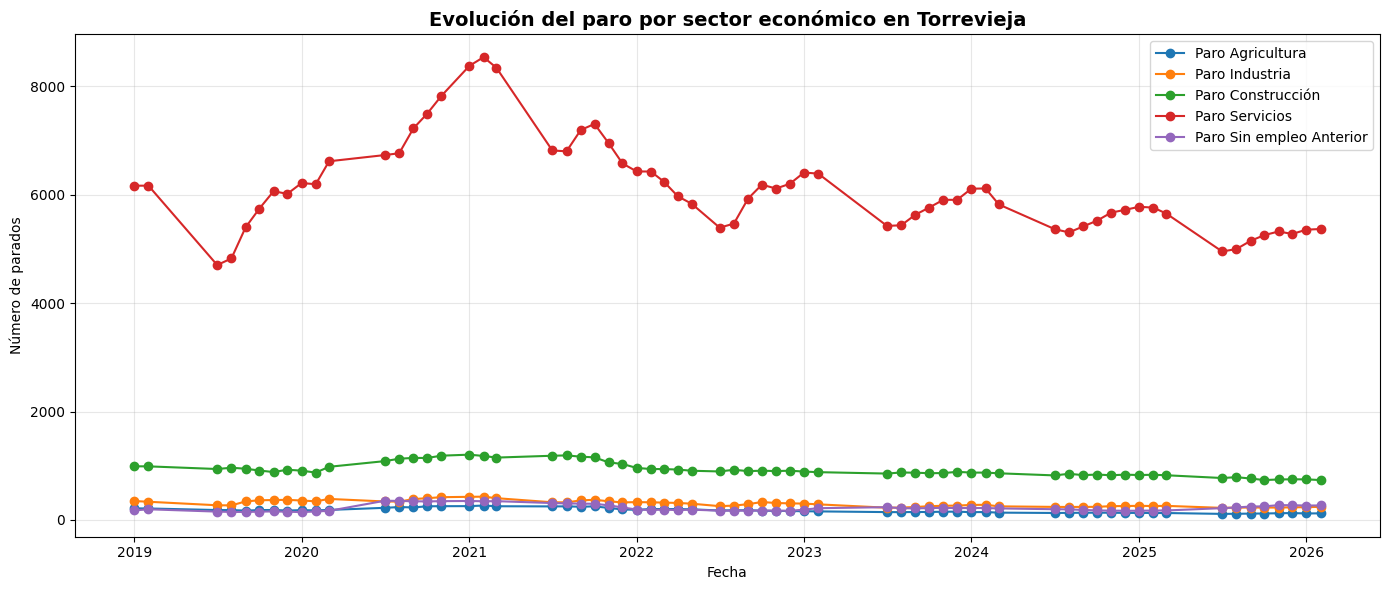

In [170]:
# Agrupar paro mensual por sector
sectores = ['Paro Agricultura', 'Paro Industria', 'Paro Construcción', 
            'Paro Servicios', 'Paro Sin empleo Anterior']

df_sectores = df_paro.groupby('fecha')[sectores].sum().reset_index()
df_sectores['mes_num'] = df_sectores['fecha'].dt.month

# Evolución temporal por sector
plt.figure(figsize=(14, 6))
for sector in sectores:
    plt.plot(df_sectores['fecha'], df_sectores[sector], marker='o', label=sector, linewidth=1.5)
plt.title('Evolución del paro por sector económico en Torrevieja', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de parados')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 INTENSIDAD DE LA ESTACIONALIDAD POR SECTOR (CV mensual)
Paro Agricultura                    CV =   6.5%
Paro Industria                      CV =   6.1%
Paro Construcción                   CV =   2.2%
Paro Servicios                      CV =   4.9%
Paro Sin empleo Anterior            CV =   8.3%


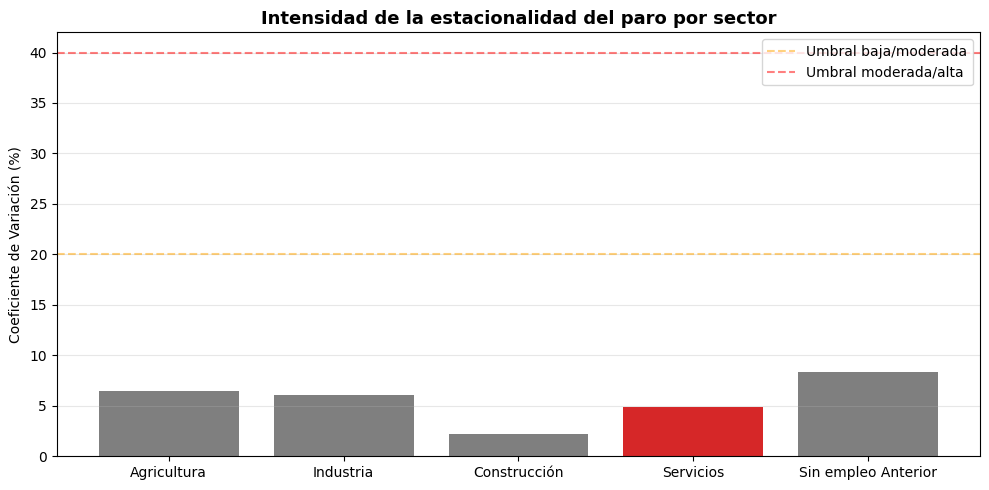

In [171]:
# CV por sector: cuánto varía el paro de cada sector entre meses
print(" INTENSIDAD DE LA ESTACIONALIDAD POR SECTOR (CV mensual)")
print("=" * 60)
cv_sectores = {}
for sector in sectores:
    media_mensual = df_sectores.groupby('mes_num')[sector].mean()
    cv = (media_mensual.std() / media_mensual.mean()) * 100
    cv_sectores[sector] = cv
    print(f"{sector:35s} CV = {cv:5.1f}%")

# Visualizamos el CV en un gráfico de barras
plt.figure(figsize=(10, 5))
sectores_plot = list(cv_sectores.keys())
valores = list(cv_sectores.values())
colores = ['tab:red' if 'Servicios' in s else 'tab:gray' for s in sectores_plot]
plt.bar([s.replace('Paro ', '') for s in sectores_plot], valores, color=colores)
plt.axhline(20, color='orange', linestyle='--', alpha=0.5, label='Umbral baja/moderada')
plt.axhline(40, color='red', linestyle='--', alpha=0.5, label='Umbral moderada/alta')
plt.title('Intensidad de la estacionalidad del paro por sector', fontsize=13, fontweight='bold')
plt.ylabel('Coeficiente de Variación (%)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

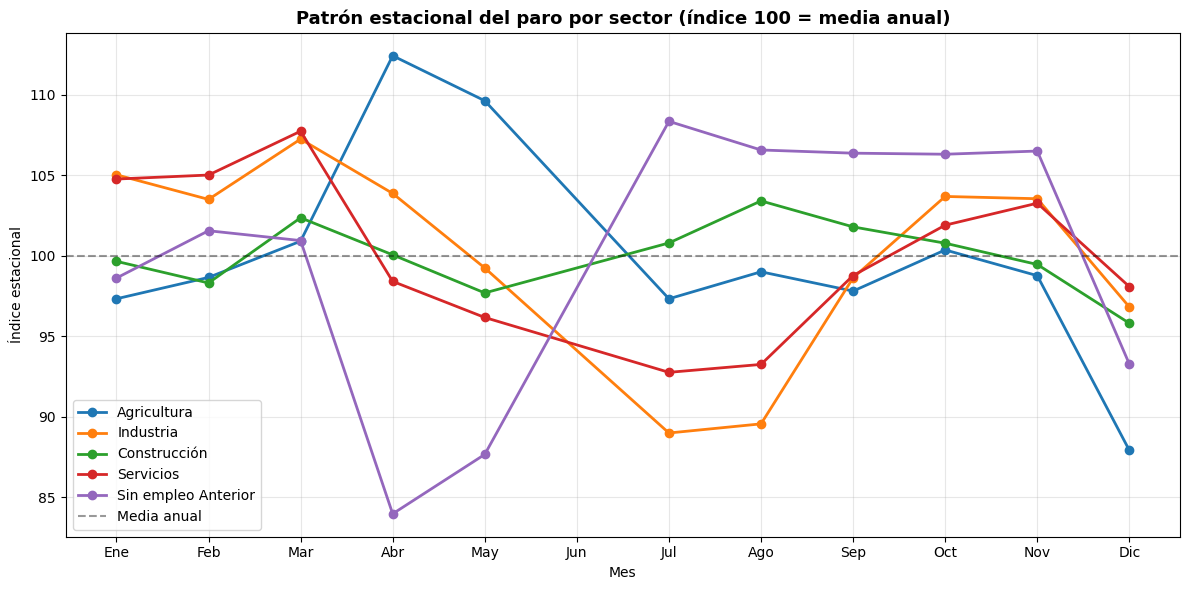

In [172]:
# Patrón estacional medio por sector (qué meses contrata cada sector)
df_sectores_mes = df_sectores.groupby('mes_num')[sectores].mean()

# Normalizamos cada serie a su propia media para poder comparar formas
df_sectores_norm = df_sectores_mes.div(df_sectores_mes.mean()) * 100

plt.figure(figsize=(12, 6))
for sector in sectores:
    plt.plot(df_sectores_norm.index, df_sectores_norm[sector], 
             marker='o', label=sector.replace('Paro ', ''), linewidth=2)
plt.axhline(100, color='black', linestyle='--', alpha=0.4, label='Media anual')
plt.title('Patrón estacional del paro por sector (índice 100 = media anual)', fontsize=13, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Índice estacional')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Mirando la gráfica podemos decir varias cosas interesantes:
1. Agricultura y sin-empleo-anterior se mueven al revés, pues presentan picos completamente opuestos y la interpretación es la siguiente: En abril, la campaña agrícola del Bajo Segura termina y eso hace que suba el paro en agricultura. Pero, al mismo tiempo, arranca la pre-temporada turística y la hostelería empieza a contratar gente sin experiencia anterior semana santa/puentes de mayo/ primera ola de extranjeros con la mejoría del tiempo climático. Es decir, abril es un mes pivote del mercado laboral en Torrevieja.

2. Servicios sí que mantiene el patrón clásico turístico con menos paro en los meses de verano. Industria presenta un valle en julio/agosto aunque quizás por cierres vacacionales y no por contratación turística.

3. La construcción es la linea más plana y estable entre todas. Es el sector con CV total más bajo, esto significa que quizás la actividad constructora está saturada.

4. Diciembre es un valle para todos los sectores, incluído sin-empleo-anterior. Puede ser porque las contrataciones de campaña de Navidad absorban paro de varios sectores.

## Relación con la estructura residencial del destino

El enunciado del reto pide explícitamente analizar la relación entre la estacionalidad y la **estructura residencial** de Torrevieja. La hipótesis a contrastar es la siguiente:

> *Torrevieja no es un destino hotelero, es un destino **residencial**. La estacionalidad turística no se explica por la oferta hotelera (que es muy escasa y casi constante todo el año) sino por la enorme masa de **segundas residencias y viviendas de uso turístico (VUT)** que se "encienden" en verano.*

Para contrastarlo, vamos a comparar el volumen de turistas mensual con dos tipos de oferta de alojamiento:
- **Hoteles activos** (oferta reglada tradicional) — ya cargados arriba.
- **Plazas en viviendas de uso turístico (VUT)** — del dataset del RETO 3.

In [173]:
# Cargamos las plazas de VUT (Viviendas de Uso Turístico) del RETO 3
plazas_vut = pd.read_csv('../DATASETS/RETO 3/DATASETS MODIFICADOS/plazas_limpio.csv', sep=';', encoding='utf-8')
plazas_vut['Fecha'] = pd.to_datetime(plazas_vut['Fecha'])
plazas_vut = plazas_vut.sort_values('Fecha')

print("Cobertura temporal VUT:", plazas_vut['Fecha'].min(), '→', plazas_vut['Fecha'].max())
print(f"Total registros: {len(plazas_vut)}")
plazas_vut.head()

Cobertura temporal VUT: 2020-08-01 00:00:00 → 2024-08-01 00:00:00
Total registros: 9


,Fecha,Año,Mes,Temporada,Plazas,Plazas por vivienda turística,Viviendas turísticas
0,2020-08-01,2020,8,Verano,18279.0,4.76,3839.0
1,2021-02-01,2021,2,Invierno,16917.0,4.74,3571.0
2,2021-08-01,2021,8,Verano,16527.0,4.75,3476.0
3,2022-02-01,2022,2,Invierno,16100.0,4.74,3397.0
4,2022-08-01,2022,8,Verano,17349.0,4.72,3679.0


In [174]:
# Comparativa: plazas hoteleras vs plazas VUT a lo largo del tiempo
# Estimamos plazas hoteleras a partir de la columna correspondiente en df1_torrevieja
# (asumimos ~50 plazas/hotel si no hay columna explícita; ajustar si el dataset tiene 'plazas')
print("Columnas hoteles:", df1_torrevieja.columns.tolist())

Columnas hoteles: ['signatura', 'cod_estado', 'estado', 'codigo_categoria', 'categoria', 'nombre', 'prov_codigo', 'provincia', 'muni_codigo', 'localidad', 'comarca', 'cp', 'direccion', 'codigo_tipo_via', 'tipo_via', 'via', 'numero', 'email', 'web', 'codigo_grupo', 'grupo', 'codigo_modalidad', 'modalidad', 'hote_totalhab', 'hote_nplazas', 'cod_cadena', 'cadena', 'fecha_alta', 'fecha_baja', 'periodo', 'dias_periodo']


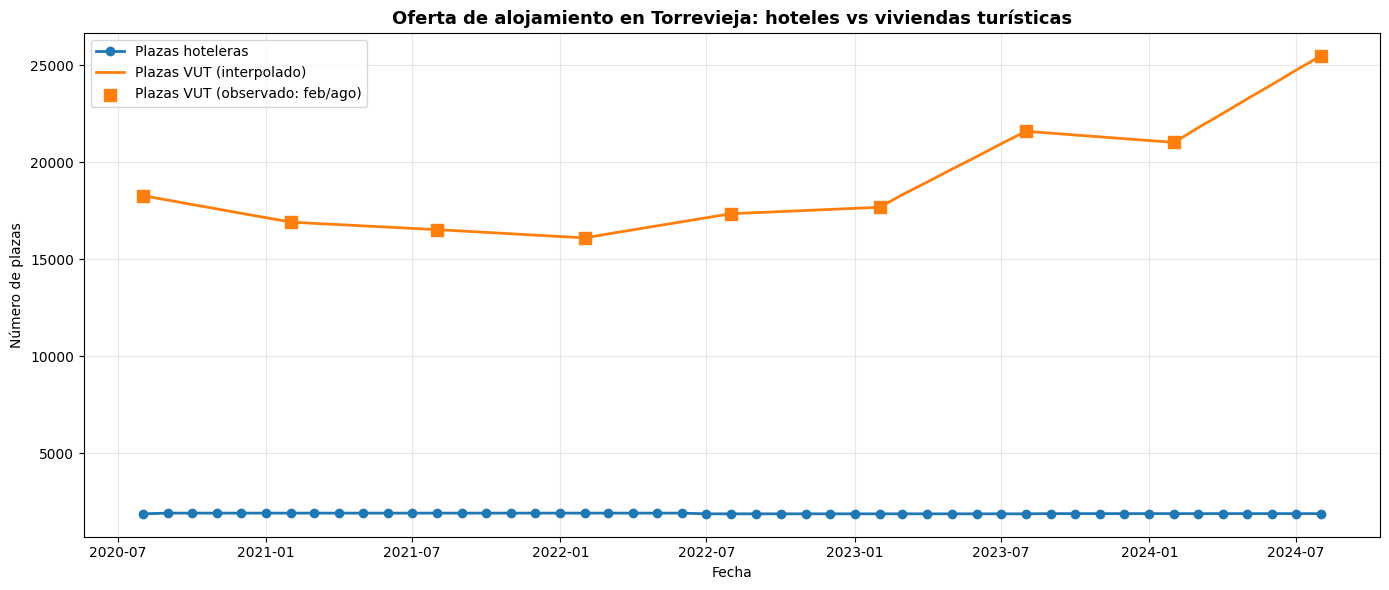


Ratio medio plazas VUT / plazas hoteleras: 9.8x


In [175]:
# Calculamos plazas hoteleras activas mensualmente
# (si existe columna de plazas, la usamos; si no, estimamos)
col_plazas_hot = None
for c in df1_torrevieja.columns:
    if 'plaza' in c.lower():
        col_plazas_hot = c
        break

fechas_comp = pd.date_range(plazas_vut['Fecha'].min(), plazas_vut['Fecha'].max(), freq='MS')
plazas_hot_mensuales = []
for fecha in fechas_comp:
    activos = df1_torrevieja[
        (df1_torrevieja['fecha_alta'] <= fecha) &
        ((df1_torrevieja['fecha_baja'].isna()) | (df1_torrevieja['fecha_baja'] > fecha))
    ]
    if col_plazas_hot:
        plazas = pd.to_numeric(activos[col_plazas_hot], errors='coerce').sum()
    else:
        plazas = activos.shape[0] * 50  # estimación ~50 plazas/hotel
    plazas_hot_mensuales.append(plazas)

df_plazas = pd.DataFrame({'fecha': fechas_comp, 'plazas_hoteles': plazas_hot_mensuales})
df_plazas = df_plazas.merge(plazas_vut[['Fecha', 'Plazas']].rename(
    columns={'Fecha': 'fecha', 'Plazas': 'plazas_vut'}), on='fecha', how='left')

# IMPORTANTE: el dataset plazas_limpio.csv solo tiene 1 punto cada 6 meses
# (siempre febrero y agosto). Para los demás meses la columna queda como NaN.
# La oferta de VUT en realidad evoluciona de forma continua entre dos mediciones,
# así que interpolamos linealmente para no introducir saltos artificiales.
df_plazas['plazas_vut_obs'] = df_plazas['plazas_vut']        # guardamos los puntos observados
df_plazas['plazas_vut'] = df_plazas['plazas_vut'].interpolate(method='linear', limit_direction='both')

plt.figure(figsize=(14, 6))
plt.plot(df_plazas['fecha'], df_plazas['plazas_hoteles'], marker='o', label='Plazas hoteleras', linewidth=2)
plt.plot(df_plazas['fecha'], df_plazas['plazas_vut'], label='Plazas VUT (interpolado)', linewidth=2, color='tab:orange')
plt.scatter(df_plazas['fecha'], df_plazas['plazas_vut_obs'], color='tab:orange', s=70, marker='s',
            zorder=5, label='Plazas VUT (observado: feb/ago)')
plt.title('Oferta de alojamiento en Torrevieja: hoteles vs viviendas turísticas', fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de plazas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ratio = df_plazas['plazas_vut'].mean() / max(df_plazas['plazas_hoteles'].mean(), 1)
print(f"\nRatio medio plazas VUT / plazas hoteleras: {ratio:.1f}x")

Como podemos ver, en los últimos años las plazas hoteleras se han mantenido constantes con variaciones no apreciables a primera vista. 

Sin embargo; la oferta de alojamientos turísticos de otro tipo sí que ha aumentado muchísimo, en particular desde el verano de 2022.

Esta subida tan brusca coincide con la popularidad en España de plataformas como Airbnb, Boking ..., y con los procesos de inscripción obligatoria que la Generalitat Valenciana ha ido endureciiendo en estos años, es decir, ala regularización forzosa de viviendas que antes operaban en negro. Aunque todo esto son hipótesis, pues no tenemos datos de Airbnb.

Si nos fijamos el ratio medio de plazas de viviendas turísticas con respecto a hoteles es 10, es decir, que, en Torrevieja, por cada plaza de hotel hay 10 plazas en viviendas turísticas, de media. Es una cifra que confirma de forma cuantitativa que el modelo de alojamiento dominante en Torrevieja no es hotelero, sino residencial-turístico.

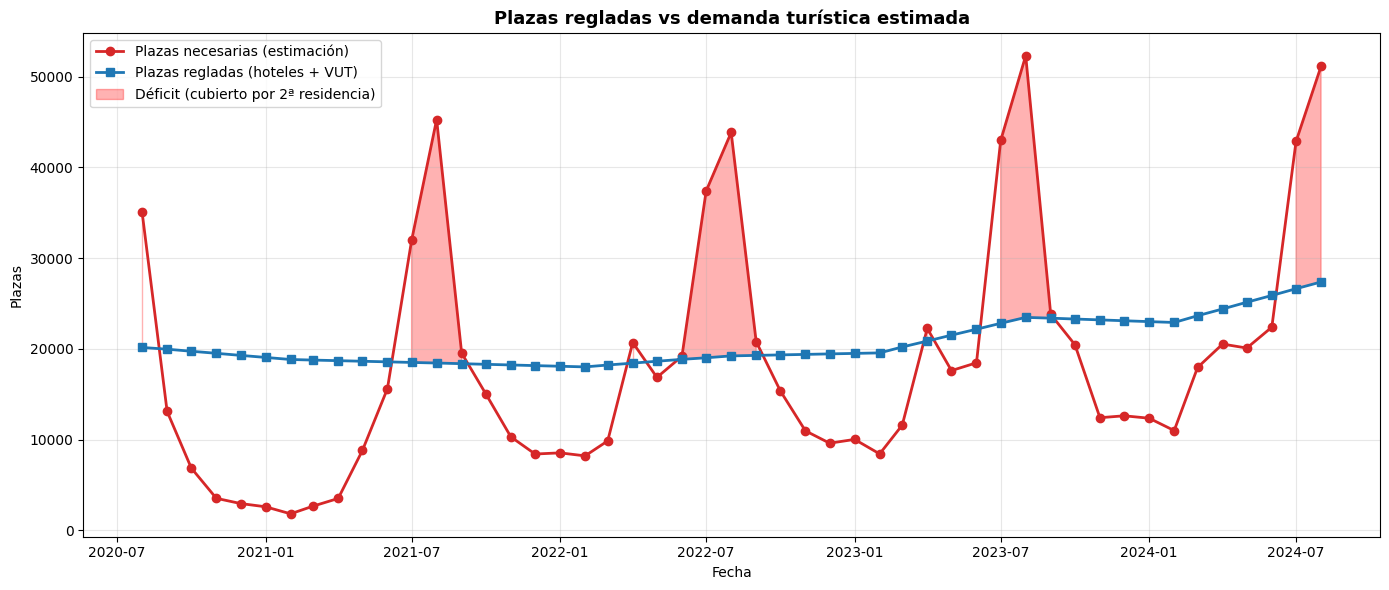

In [176]:
# ¿Pueden los hoteles + VUT por sí solos explicar el pico de turistas en verano?
# Cruzamos plazas totales con turistas mensuales para ver el "déficit estructural".
# plazas_vut ya viene interpolada de la celda anterior, así que no hay saltos artificiales.

df_plazas['plazas_totales'] = df_plazas['plazas_hoteles'].fillna(0) + df_plazas['plazas_vut'].fillna(0)

# La nueva versión de poblacion_efectiva ya tiene las dos columnas separadas; sumamos directamente.
turismo_mensual_total = poblacion_efectiva[['fecha']].copy()
turismo_mensual_total['turistas_total'] = (
    poblacion_efectiva['turismo_interno'] + poblacion_efectiva['turismo_receptor']
)

comp_plazas = df_plazas.merge(turismo_mensual_total[['fecha', 'turistas_total']], on='fecha', how='inner')
# Asumimos estancia media ~7 días → cada turista ocupa una plaza durante una semana del mes
# Plazas-mes equivalentes que harían falta = turistas / 4 (aprox 4 semanas/mes)
comp_plazas['plazas_necesarias'] = comp_plazas['turistas_total'] / 4

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(comp_plazas['fecha'], comp_plazas['plazas_necesarias'], 
        marker='o', label='Plazas necesarias (estimación)', linewidth=2, color='tab:red')
ax.plot(comp_plazas['fecha'], comp_plazas['plazas_totales'], 
        marker='s', label='Plazas regladas (hoteles + VUT)', linewidth=2, color='tab:blue')
ax.fill_between(comp_plazas['fecha'], comp_plazas['plazas_totales'], comp_plazas['plazas_necesarias'],
                where=comp_plazas['plazas_necesarias'] > comp_plazas['plazas_totales'],
                alpha=0.3, color='red', label='Déficit (cubierto por 2ª residencia)')
ax.set_title('Plazas regladas vs demanda turística estimada', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Plazas')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La oferta reglada (hoteles + VUT) está muy por debajo de la demanda turística en los meses pico. Esa "zona roja" entre las dos líneas solo puede ser absorbida por viviendas de segunda residencia no registradas como turísticas: pisos vacíos en invierno que sus dueños ocupan en verano o ceden a familiares.

No obstante, el valle invernal de demanda está muy por debajo de la oferta reglada en todos los años. Esto sugiere que la oferta reglada podría reducirse en invierno (cierres temporales, reformas, alquileres residenciales temporales) sin comprometer la demanda. Es la otra cara del problema: no es solo "falta oferta en agosto", es también "sobra oferta de noviembre a marzo".

Esto explica tres cosas que veíamos antes pero no podíamos demostrar:

1. Por qué el turismo nacional cayó menos que el extranjero en 2020-2021: la segunda residencia es un alojamiento "propio", inmune a las restricciones hoteleras del COVID.
2. Por qué la curva de hoteles activos es prácticamente plana mientras la de turistas oscila de forma extrema: la oferta hotelera no es la variable que absorbe la estacionalidad.
3. Por qué la estacionalidad de Torrevieja es tan brutal comparada con destinos hoteleros como Benidorm: una vivienda hotelera factura 12 meses al año, una segunda residencia se ocupa 2-3 meses al año.

La estructura residencial de Torrevieja es la causa estructural de su estacionalidad extrema, no una consecuencia.

Como última sección de este reto vamos a tratar de estimar el gasto turístico en Torrevieja mediante una fórmula realista y reproducible, que es:

    gasto_municipal_mes ≈ pernoctaciones_estimadas × gasto_medio_diario_EGATUR

de donde las pernoctaciones_estimadas las tenemos previamente calculadas en el RETO 1 y el gasto_medio_diario_EGATUR lo podemos sacar del INE ya que es una Encuesta de Gasto Turístico. Es nacional pero lo podemos acotar por CCAA (Costa Blanca en nuestro caso).
La tabla FAMILITUR sería el equivalente del INE pero para el turismo nacional.

De esta forma podríamos calcular el gasto mensual como sigue:

    gasto_torrevieja_mes ≈ turismo_receptor × gasto_medio_diario_EGATUR_CV   × estancia_media + turismo_interno × gasto_medio_diario_FAMILITUR_CV × estancia_media


In [177]:
egatur = pd.read_csv('../DATASETS/RETO 2/gasto_turistico/egatur.csv', sep=';', encoding='latin-1', decimal =',', thousands='.')
egatur.columns = egatur.columns.str.strip()
egatur['fecha'] = pd.to_datetime(egatur['Periodo'], format='%YM%m')

# Pivotar: filas = mes + motivo del viaje, columnas = concepto
egatur_wide = egatur.pivot_table(
    index=['fecha', 'Motivo del viaje'],
    columns='Gastos y duración media de los viajes',
    values='Total',
    aggfunc='first'
).reset_index()

# Renombrar para que sea cómodo de usar
egatur_wide = egatur_wide.rename(columns={
    'Gasto total': 'gasto_total_mEUR',
    'Gasto medio por persona': 'gasto_medio_persona',
    'Gasto medio diario por persona': 'gasto_medio_diario',
    'Duración media de los viajes': 'duracion_media',
})

egatur_ocio = (
    egatur_wide[egatur_wide['Motivo del viaje'] == 'Ocio, recreo y vacaciones']
    .drop(columns='Motivo del viaje')
    .sort_values('fecha')
    .reset_index(drop=True)
)
egatur_ocio.head()



Gastos y duración media de los viajes,fecha,duracion_media,gasto_medio_diario,gasto_medio_persona,gasto_total_mEUR
0,2018-01-01,7.98,136.0,1087.0,3763.51
1,2018-02-01,7.50,142.0,1065.0,3682.75
2,2018-03-01,7.57,142.0,1071.0,4649.70
3,2018-04-01,6.69,145.0,971.0,5617.78
4,2018-05-01,6.68,150.0,1005.0,7187.72


In [178]:
familitur = pd.read_csv('../DATASETS/RETO 2/gasto_turistico/familitur.csv', sep=';', encoding='latin-1', decimal=',', thousands='.')
familitur.columns = familitur.columns.str.strip()
familitur['año']   = familitur['Periodo'].astype(int)
familitur['fecha'] = pd.to_datetime(familitur['año'], format='%Y')   # 1 de enero de cada año

# Pivotar: filas = año + tipo de destino, columnas = concepto
familitur_wide = familitur.pivot_table(
    index=['fecha', 'año', 'Tipo de destino'],
    columns='Concepto turístico',
    values='Total',
    aggfunc='first'
).reset_index()

# Renombrar para que sea cómodo de usar
familitur_wide = familitur_wide.rename(columns={
    'Viajes': 'viajes',
    'Pernoctaciones': 'pernoctaciones',
    'Duración media de los viajes': 'duracion_media_nacional',
    'Gasto total': 'gasto_total_mEUR_nacional',
    'Gasto medio por persona': 'gasto_medio_persona_nacional',
    'Gasto medio diario por persona': 'gasto_medio_diario_nacional',
})
# Cogemos solo los viajes con mtivos de ocio, que son los puramente turísticos
familitur_otraCA = (
    familitur_wide[familitur_wide['Tipo de destino'] == 'A otra Comunidad Autónoma']
    .drop(columns='Tipo de destino')
    .sort_values('año')
    .reset_index(drop=True)
)
familitur_otraCA.head()

Concepto turístico,fecha,año,duracion_media_nacional,gasto_medio_diario_nacional,gasto_medio_persona_nacional,gasto_total_mEUR_nacional,pernoctaciones,viajes
0,2018-01-01,2018,4.57,56.93,260.23,21788081.18,382722163.0,83726593.0
1,2019-01-01,2019,4.63,58.38,270.38,22462105.74,384740039.0,83075463.0
2,2020-01-01,2020,6.15,46.03,283.26,11034452.81,239704583.0,38955673.0
3,2021-01-01,2021,5.31,58.19,308.89,18078795.37,310685588.0,58528956.0
4,2022-01-01,2022,4.76,68.69,327.07,24920854.53,362795286.0,76194865.0


In [182]:
# === ESTIMACIÓN DEL GASTO TURÍSTICO MENSUAL EN TORREVIEJA ===

# --- 0) Forzar 'fecha' y 'año' como columnas en poblacion_efectiva ---
pe = poblacion_efectiva.copy()
if 'fecha' not in pe.columns:                       # estaba como índice
    pe = pe.reset_index()
pe['fecha']   = pd.to_datetime(pe['fecha'])
pe['año']     = pe['fecha'].dt.year.astype(int)
pe['mes_num'] = pe['fecha'].dt.month.astype(int)
print('pe.columns ->', pe.columns.tolist())
assert 'fecha' in pe.columns and 'año' in pe.columns

# --- 1) Auxiliar EGATUR (mensual) ----------------------------------
ee = egatur_ocio.copy()
if 'fecha' not in ee.columns:
    ee = ee.reset_index()
ee['fecha'] = pd.to_datetime(ee['fecha'])
print('ee.columns ->', ee.columns.tolist())
assert 'gasto_medio_persona' in ee.columns, "Reejecuta el pivot de EGATUR"

# --- 2) Auxiliar FAMILITUR (anual) ---------------------------------
fn = familitur_otraCA.copy()
if 'año' not in fn.columns:
    fn = fn.reset_index()
fn['año'] = fn['año'].astype(int)
print('fn.columns ->', fn.columns.tolist())
assert 'gasto_medio_persona_nacional' in fn.columns, "Reejecuta el pivot de FAMILITUR"

# --- 3) Construcción de gasto --------------------------------------
gasto = pe[['fecha', 'año', 'mes_num',
            'turismo_interno', 'turismo_receptor']].copy()
print('gasto antes de merges ->', gasto.columns.tolist())

gasto = gasto.merge(ee[['fecha', 'gasto_medio_persona',
                        'gasto_medio_diario', 'duracion_media']],
                    on='fecha', how='left')

gasto = gasto.merge(fn[['año', 'gasto_medio_persona_nacional',
                        'gasto_medio_diario_nacional', 'duracion_media_nacional']],
                    on='año', how='left')

print('gasto tras merges ->', gasto.columns.tolist())
assert 'fecha' in gasto.columns, "Algo se llevó por delante 'fecha' en los merges"

# --- 4) Cálculo del gasto estimado ---------------------------------
gasto['gasto_extranjero_eur'] = gasto['turismo_receptor'] * gasto['gasto_medio_persona']
gasto['gasto_nacional_eur']   = gasto['turismo_interno']  * gasto['gasto_medio_persona_nacional']
gasto['gasto_total_eur']      = gasto['gasto_extranjero_eur'] + gasto['gasto_nacional_eur']

for col in ['gasto_extranjero_eur', 'gasto_nacional_eur', 'gasto_total_eur']:
    gasto[col.replace('_eur', '_mEUR')] = gasto[col] / 1_000_000

# --- 5) Mostrar últimos 12 meses -----------------------------------
gasto[['fecha', 'turismo_receptor', 'turismo_interno',
       'gasto_extranjero_mEUR', 'gasto_nacional_mEUR',
       'gasto_total_mEUR']].sort_values('fecha').tail(12)


pe.columns -> ['fecha', 'turismo_interno', 'turismo_receptor', 'turismo_emisor', 'año', 'poblacion_base', 'poblacion_efectiva', 'mes_num', 'mes_nombre']
ee.columns -> ['fecha', 'duracion_media', 'gasto_medio_diario', 'gasto_medio_persona', 'gasto_total_mEUR']
fn.columns -> ['fecha', 'año', 'duracion_media_nacional', 'gasto_medio_diario_nacional', 'gasto_medio_persona_nacional', 'gasto_total_mEUR_nacional', 'pernoctaciones', 'viajes']
gasto antes de merges -> ['fecha', 'año', 'mes_num', 'turismo_interno', 'turismo_receptor']
gasto tras merges -> ['fecha', 'año', 'mes_num', 'turismo_interno', 'turismo_receptor', 'gasto_medio_persona', 'gasto_medio_diario', 'duracion_media', 'gasto_medio_persona_nacional', 'gasto_medio_diario_nacional', 'duracion_media_nacional']


,fecha,turismo_receptor,turismo_interno,gasto_extranjero_mEUR,gasto_nacional_mEUR,gasto_total_mEUR
54,2024-01-01,32656.0,16791,43.922320,5.858044,49.780364
55,2024-02-01,28391.0,15610,37.760030,5.446017,43.206047
56,2024-03-01,36569.0,35259,49.514426,12.301160,61.815586
57,2024-04-01,49437.0,32707,60.164829,11.410818,71.575647
58,2024-05-01,50842.0,29546,61.976398,10.308008,72.284406
59,2024-06-01,54659.0,34939,70.400792,12.189518,82.590310
60,2024-07-01,80148.0,91328,114.291048,31.862513,146.153561
61,2024-08-01,86083.0,118533,121.979611,41.353793,163.333404
62,2024-09-01,58857.0,45270,77.220384,15.793798,93.014182
63,2024-10-01,58955.0,18636,76.523590,6.501728,83.025318


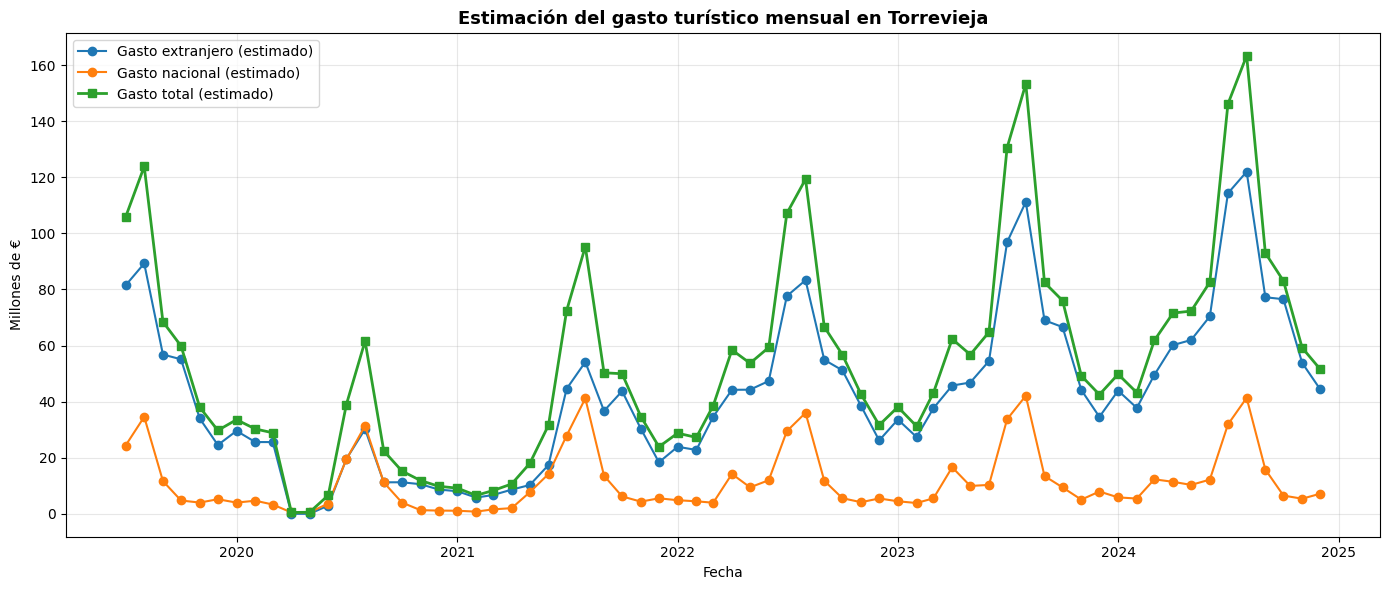

In [184]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gasto['fecha'], gasto['gasto_extranjero_mEUR'],
        marker='o', label='Gasto extranjero (estimado)', color='tab:blue')
ax.plot(gasto['fecha'], gasto['gasto_nacional_mEUR'],
        marker='o', label='Gasto nacional (estimado)', color='tab:orange')
ax.plot(gasto['fecha'], gasto['gasto_total_mEUR'],
        marker='s', label='Gasto total (estimado)', color='tab:green', linewidth=2)
ax.set_title('Estimación del gasto turístico mensual en Torrevieja',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Millones de €')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



El patrón estacional del gasto es igual que el del paro, y la venida de los turistas, es muy claro, con valles invernales muy bajos y picos de verano muy pronunciados.

También se aprecia que el gasto nacional es mucho más bajo que el gasto extranjero. 

También es interesante en la gráfica el impacto del COVID en el gasto, pues a partir de 2020 se desploma, sobre todo el extranjero, que no se empieza a recuperar hasta el verano de 2021, y ya en 2022 se despega completamente del nacional. El nacional, no obstante, se mantiene bastante constante, porque como ya vimos los turistas nacionales se mantuvieron constantes. Esto a su vez está relacionado con las segundas residencias,, pues el no tener que pagar alquiler vacacional obviamente hace que se gaste menos.

El crecimiento del gasto turístico en Torrevieja es enteramente extranjero.

CV del gasto turístico mensual: 54.3%
Ratio pico/valle: 4.31x
Concentración en Jul-Ago-Sep: 44.5%


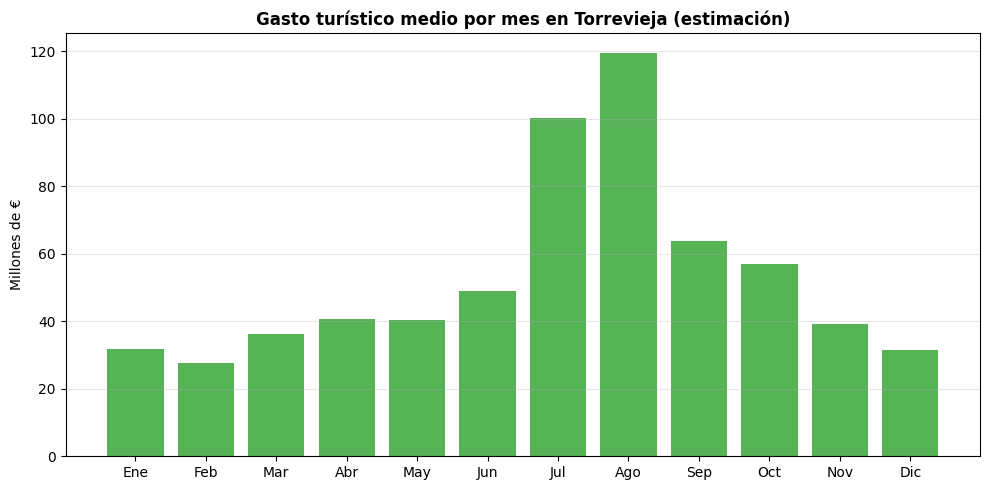

In [185]:
# --- 6) Estacionalidad del gasto: patrón mensual medio ----------------
gasto_mes = gasto.groupby('mes_num')['gasto_total_mEUR'].mean()

cv_gasto = (gasto_mes.std() / gasto_mes.mean()) * 100
ratio_pv = gasto_mes.max() / gasto_mes.min()
concentracion_jul_sep = gasto_mes.loc[[7, 8, 9]].sum() / gasto_mes.sum() * 100

print(f"CV del gasto turístico mensual: {cv_gasto:.1f}%")
print(f"Ratio pico/valle: {ratio_pv:.2f}x")
print(f"Concentración en Jul-Ago-Sep: {concentracion_jul_sep:.1f}%")

plt.figure(figsize=(10, 5))
plt.bar(range(1, 13), gasto_mes.values, color='tab:green', alpha=0.8)
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.title('Gasto turístico medio por mes en Torrevieja (estimación)',
          fontsize=12, fontweight='bold')
plt.ylabel('Millones de €')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

La concentración del gasto en julio-agosto es brutal, de aproximadamente 120M de euros. En el mes pico, que es agosto, se gasta casi 4.5 veces mñas que en el mes valle, que es febrero.

Además, en el gráfico se aprecian 3 estaciones claras:
1. Temporada alta, que cubre los meses de julio y agosto y cubre alrededor del 35% del gasto anual.
2. Temporada media, que se correspondería con los meses colindantes a los de la temporada alta, es decir, junio. septiembre y octubre. Se sigue gasrando en un rango de 50-65M al mes.
3. Temporada baja, que cubre el resto de meses y en la que se gasta menos de 40M de euros al mes.

Dos últimos puntos interesantes a destacar mirando la gráfica son: que el gasto en octubre es mucho más alto que em meses de más calor como abril y mayo, pese a que en términos de turistas suelen ser similares, lo que sugiere que, aunquee el efecto Semana Snta existe, como ya vimos en la gráfica del paro, no rompe la estacionalidad anual del gasto. Y, por otro lado, Torrevieja depende económicamente casi por completo del turista extranjero, que es el que más gasta. Esto significa que la diversificación está empeorando, no mejorando y, por tanto, cualquier shock en mercados emisores (Alemania en recesón, regulación europea de vivienda turística...) impactaría desproporcionadamente al destino.

## Hasta qué punto los datos disponibles permiten describir la estacionalidad

El enunciado del reto pide también valorar **las limitaciones de los datos**. Hacemos un balance crítico:

### Cobertura temporal
- **Paro**: solo desde 2019. La Generalitat Valenciana publica series desde mucho antes; usar 2010+ permitiría aislar el efecto COVID y ver la estacionalidad pre-crisis. Con 7 años apenas tenemos margen para distinguir tendencia de ciclo.
- **Turismo (poblacion_efectiva)**: 2019+, misma limitación.
- **Hoteles**: histórico completo de altas/bajas, pero sin información mensual de **ocupación** (solo si están abiertos o no), lo que limita el análisis al *stock* de oferta y no al *uso* real.
- **VUT**: solo desde 2020.

### Granularidad
- Los datos son **mensuales**. La estacionalidad real en Torrevieja tiene componente **semanal** (puentes, Semana Santa, fines de semana de agosto) y **diaria** (efecto fin de semana). Con datos mensuales perdemos toda la microestacionalidad. Sería ideal disponer de datos diarios de:
  - Pernoctaciones (INE no las publica a nivel municipal con esta granularidad).
  - Consumo eléctrico residencial (proxy clásico de ocupación de segunda residencia).
  - Generación de residuos urbanos.
  - Tráfico en accesos a la ciudad.

### Variables ausentes
- No hay datos de gasto turístico en Torrevieja reales: sabemos cuántos vienen pero no cuánto gastan, solo podemos estimarlo con datos a nivel nacional, lo que limita el análisis de "implicaciones económicas". Además, los proxies más finos para estimar este gasto suelen ser los de gastos de tarjetas y esos que se pueden conseguir en fuentes como Hacienda, BBVA Daata & Analytics o Visa Businesss Insights, son siempre privados o de pago.
- No hay datos de empleo turístico directo. Solo paro, que es la cara contraria.
- No hay datos de capacidad de servicios públicos (camas hospitalarias, agua, residuos) para cuantificar la presión sobre el destino que pide el enunciado.

### Conclusión
Los datos disponibles permiten describir cualitativamente y cuantificar de forma agregada la estacionalidad (CV, ratio pico/valle, correlación paro-turismo), pero no permiten:
- Medir la intensidad real en el momento de máxima afluencia (ej. la primera semana de agosto).
- Estimar cuántas viviendas se ocupan estacionalmente (la diferencia entre nuestra estimación de "déficit de plazas" y la realidad puede ser muy grande).
- Cuantificar el impacto sobre servicios públicos.

